# 01. Análisis y preparación de datos

Este notebook construye el conjunto de modelización a partir de los registros hipotecarios de 2019 a 2024. Incluye la revisión de calidad, el tratamiento de valores ausentes y extremos, la transformación de variables y el análisis exploratorio previo al modelado.

**Entrada:** archivos anuales en `data/raw/`.

**Salida:** `data/processed/df_model.pkl`, utilizado en las etapas posteriores.


## 1. Carga y revisión inicial


## Importamos librerias


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as smdime 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency


## Importamos Dataset


Juntando todos los csv


In [2]:
df_2019 = pd.read_csv("data/raw/newbancos2019.csv")
df_2020 = pd.read_csv("data/raw/newbancos2020.csv")
df_2021 = pd.read_csv("data/raw/newbancos2021.csv")
df_2022 = pd.read_csv("data/raw/newbancos2022.csv")
df_2023 = pd.read_csv("data/raw/newbancos2023.csv")
df_2024 = pd.read_csv("data/raw/newbancos2024.csv")


df_2019["year"] = 2019
df_2020["year"] = 2020
df_2021["year"] = 2021
df_2022["year"] = 2022
df_2023["year"] = 2023
df_2024["year"] = 2024

df = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023, df_2024], ignore_index=True)


C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2851387778.py:1: DtypeWarning: Columns (0: total_units, 1: debt_to_income_ratio) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2019 = pd.read_csv("newbancos2019.csv")
C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2851387778.py:2: DtypeWarning: Columns (0: total_units, 1: debt_to_income_ratio) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2020 = pd.read_csv("newbancos2020.csv")
C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2851387778.py:3: DtypeWarning: Columns (0: total_units, 1: debt_to_income_ratio) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2021 = pd.read_csv("newbancos2021.csv")
C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2851387778.py:4: DtypeWarning: Columns (0: total_units, 1: debt_to_income_ratio) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2022 = pd.re

## Información general del dataset


In [3]:
df


,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,year
0,2019,AD6GFRVSDT01YPT1CS68,21500,PA,42049.0,4.204901e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,6443,11.35,66800,113.0,844,1830,43,2019
1,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
2,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
3,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
4,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4363596,2024,E57ODZWZ7FF32TWEFA76,99999,NaN,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2024
4363597,2024,E57ODZWZ7FF32TWEFA76,99999,NaN,NaN,NaN,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2024
4363598,2024,E57ODZWZ7FF32TWEFA76,99999,NaN,NaN,NaN,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2024
4363599,2024,E57ODZWZ7FF32TWEFA76,99999,NaN,NaN,NaN,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2024


In [4]:
df.head(5)


,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,year
0,2019,AD6GFRVSDT01YPT1CS68,21500,PA,42049.0,4.204901e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,6443,11.35,66800,113.0,844,1830,43,2019
1,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
2,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
3,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019
4,2019,AD6GFRVSDT01YPT1CS68,0,NaN,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,0,0.00,0,0.0,0,0,0,2019


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4363601 entries, 0 to 4363600
Data columns (total 100 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       str    
 2   derived_msa-md                            int64  
 3   state_code                                str    
 4   county_code                               float64
 5   census_tract                              float64
 6   conforming_loan_limit                     str    
 7   derived_loan_product_type                 str    
 8   derived_dwelling_category                 str    
 9   derived_ethnicity                         str    
 10  derived_race                              str    
 11  derived_sex                               str    
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  preapproval 

In [6]:
df.dtypes


activity_year                          int64
lei                                      str
derived_msa-md                         int64
state_code                               str
county_code                          float64
                                      ...   
tract_to_msa_income_percentage       float64
tract_owner_occupied_units             int64
tract_one_to_four_family_homes         int64
tract_median_age_of_housing_units      int64
year                                   int64
Length: 100, dtype: object

In [7]:
list(df.columns)


['activity_year',
 'lei',
 'derived_msa-md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open-end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'income',
 '

In [8]:
df.shape


(4363601, 100)

### Revisión de variables


In [9]:
df['business_or_commercial_purpose'].value_counts()


business_or_commercial_purpose
2    4258643
1     104958
Name: count, dtype: int64

In [10]:
(3628075/3708043)*100


97.84339070501609

In [11]:
df['business_or_commercial_purpose'].isna().sum()


np.int64(0)

## 2. Estadísticos descriptivos


In [12]:
df.describe()


,activity_year,derived_msa-md,county_code,census_tract,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,...,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,year
count,4.363601e+06,4.363601e+06,4.320430e+06,4.320430e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,...,64807.000000,6929.000000,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06,4.363601e+06
mean,2.020815e+03,3.485410e+04,2.620154e+04,2.620175e+10,2.989817e+00,8.274551e-01,1.979224e+00,1.045053e+00,1.398038e+01,1.194536e+00,...,5.055982,5.823784,5.393184e+03,3.702220e+01,8.905931e+04,1.193364e+02,1.357272e+03,1.790410e+03,3.672365e+01,2.020815e+03
std,1.531018e+00,2.029966e+04,1.623633e+04,1.623632e+10,1.928364e+00,2.749419e+00,1.426328e-01,2.750203e-01,1.457247e+01,3.958430e-01,...,2.715384,2.757203,3.014725e+03,2.658514e+01,2.329565e+04,5.131969e+01,8.424289e+02,1.045322e+03,1.923102e+01,1.531018e+00
min,2.019000e+03,0.000000e+00,1.001000e+03,1.001020e+09,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,2.019000e+03
25%,2.020000e+03,1.974000e+04,1.202100e+04,1.202100e+10,1.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,4.000000,4.000000,3.668000e+03,1.549000e+01,7.480000e+04,8.657000e+01,8.450000e+02,1.190000e+03,2.200000e+01,2.020000e+03
50%,2.021000e+03,3.482000e+04,2.608100e+04,2.608101e+10,3.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,1.000000e+00,...,5.000000,6.000000,4.927000e+03,3.007000e+01,8.480000e+04,1.120000e+02,1.241000e+03,1.653000e+03,3.500000e+01,2.021000e+03
75%,2.022000e+03,4.110000e+04,3.915300e+04,3.915353e+10,4.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,3.100000e+01,1.000000e+00,...,6.000000,9.000000,6.452000e+03,5.431000e+01,1.009000e+05,1.438400e+02,1.702000e+03,2.197000e+03,5.100000e+01,2.022000e+03
max,2.024000e+03,9.999900e+04,7.212700e+04,7.212701e+10,8.000000e+00,7.200000e+01,2.000000e+00,4.000000e+00,3.200000e+01,2.000000e+00,...,9.000000,9.000000,5.381200e+04,1.000000e+02,2.013000e+05,5.074700e+02,1.952900e+04,2.539100e+04,8.000000e+01,2.024000e+03


## 3. Variables categóricas


In [13]:
df.describe(include='object')


C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2878739399.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,lei,state_code,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,total_units,debt_to_income_ratio,applicant_age,co-applicant_age,applicant_age_above_62,co-applicant_age_above_62
count,4363601,4320415,4362473,4363601,4363601,4363601,4363601,4363601,4363601,2764006,4363601,4363601,4363520,185740
unique,6,53,3,7,4,5,6,2,13,19,8,10,2,2
top,KB1H1DSPRFMYMCUFXT09,CA,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,1,20%-<30%,35-44,9999,No,No
freq,1633759,632507,4012825,3385537,4333752,3668750,3263223,2635133,3914447,494878,1054305,4175924,3493121,138536


Categorias que toma cada variable categórica


In [14]:
df.select_dtypes(include='object').nunique()


C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\2001172712.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


lei                           6
state_code                   53
conforming_loan_limit         3
derived_loan_product_type     7
derived_dwelling_category     4
derived_ethnicity             5
derived_race                  6
derived_sex                   2
total_units                  13
debt_to_income_ratio         19
applicant_age                 8
co-applicant_age             10
applicant_age_above_62        2
co-applicant_age_above_62     2
dtype: int64

## 4. Variables numéricas


In [15]:
df.select_dtypes(include='number').columns


Index(['activity_year', 'derived_msa-md', 'county_code', 'census_tract',
       'action_taken', 'purchaser_type', 'preapproval', 'loan_type',
       'loan_purpose', 'lien_status', 'reverse_mortgage',
       'open-end_line_of_credit', 'business_or_commercial_purpose',
       'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread',
       'hoepa_status', 'total_loan_costs', 'total_points_and_fees',
       'origination_charges', 'discount_points', 'lender_credits', 'loan_term',
       'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization',
       'interest_only_payment', 'balloon_payment',
       'other_nonamortizing_features', 'property_value', 'construction_method',
       'occupancy_type', 'manufactured_home_secured_property_type',
       'manufactured_home_land_property_interest',
       'multifamily_affordable_units', 'income', 'applicant_credit_score_type',
       'co-applicant_credit_score_type', 'applicant_ethnicity-1',
       'applicant_ethnicity-2',

## 5. Missings


In [16]:
df.isna().mean().sort_values(ascending=False)


aus-4                                1.000000
aus-5                                1.000000
co-applicant_ethnicity-5             1.000000
co-applicant_ethnicity-4             0.999999
co-applicant_race-5                  0.999998
                                       ...   
tract_to_msa_income_percentage       0.000000
tract_owner_occupied_units           0.000000
tract_one_to_four_family_homes       0.000000
tract_median_age_of_housing_units    0.000000
year                                 0.000000
Length: 100, dtype: float64

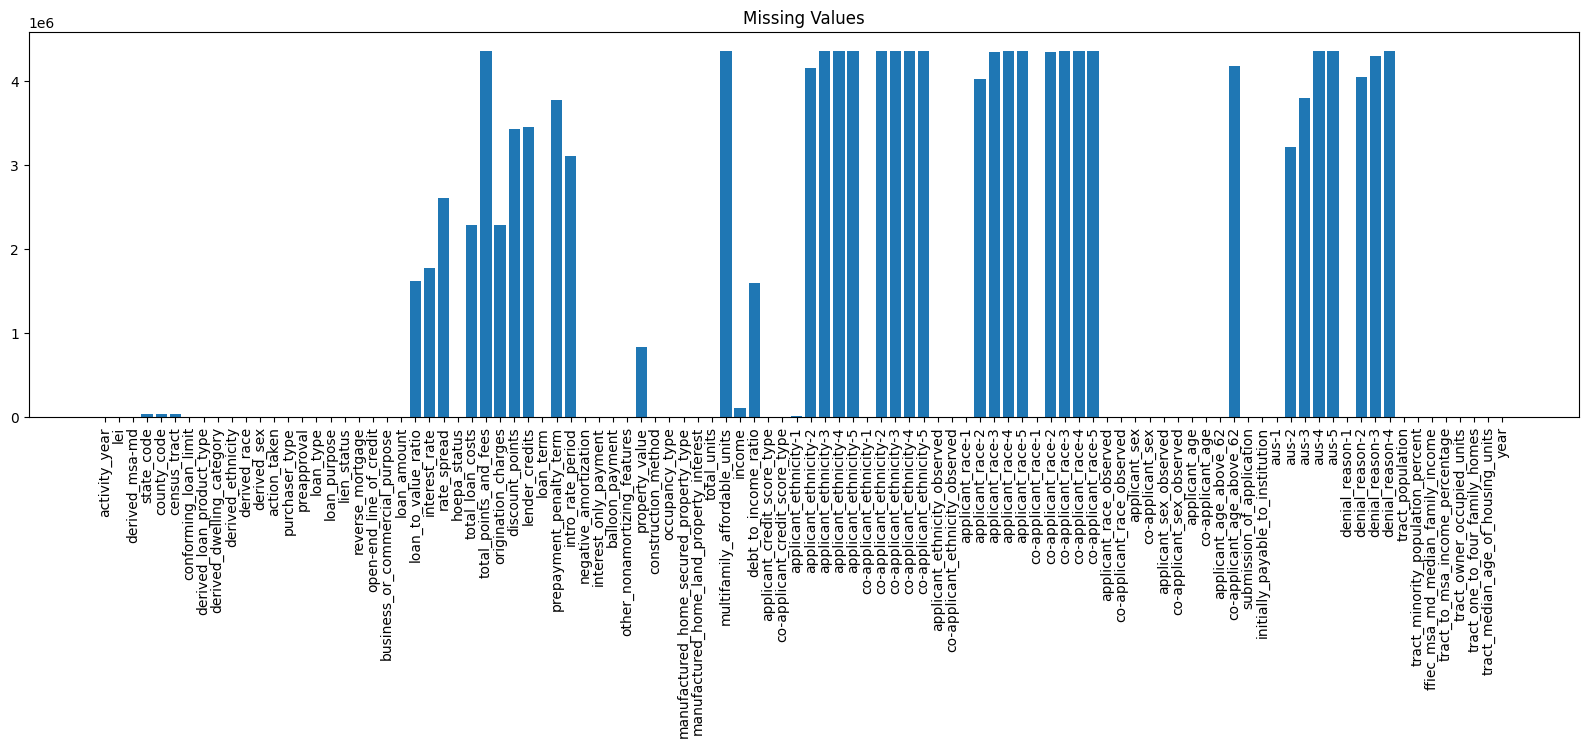

In [17]:
missing = list(df.isna().sum())

plt.figure(figsize=(20, 5))
plt.bar(df.columns, missing)
plt.xticks(rotation=90)
plt.title('Missing Values')
plt.show()


Aún no se tratan puesto que solo es para ver qué numero de missings hay con el objetivo de reducir el dataset y hacelo más robusto.


## 6. Outliers


In [18]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Filtrar solo variables con muchos valores únicos
continuous_cols = [col for col in num_cols if df[col].nunique() > 20] # nos quedamos únicamente con variables numericas que tengan más de 20 valores distintos. 

print(continuous_cols)


['derived_msa-md', 'county_code', 'census_tract', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'intro_rate_period', 'property_value', 'income', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes', 'tract_median_age_of_housing_units']


In [19]:
outlier_summary = {}

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = n_outliers

for col, n in sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{col}: {n} outliers")


loan_term: 1117390 outliers
income: 362385 outliers
loan_amount: 352351 outliers
property_value: 306411 outliers
derived_msa-md: 283266 outliers
intro_rate_period: 247209 outliers
tract_to_msa_income_percentage: 200191 outliers
origination_charges: 189875 outliers
ffiec_msa_md_median_family_income: 178048 outliers
tract_population: 176029 outliers
tract_one_to_four_family_homes: 167962 outliers
interest_rate: 155975 outliers
rate_spread: 140700 outliers
tract_owner_occupied_units: 137344 outliers
total_loan_costs: 126701 outliers
lender_credits: 105488 outliers
discount_points: 69349 outliers
loan_to_value_ratio: 19039 outliers
total_points_and_fees: 3 outliers
county_code: 0 outliers
census_tract: 0 outliers
tract_minority_population_percent: 0 outliers
tract_median_age_of_housing_units: 0 outliers


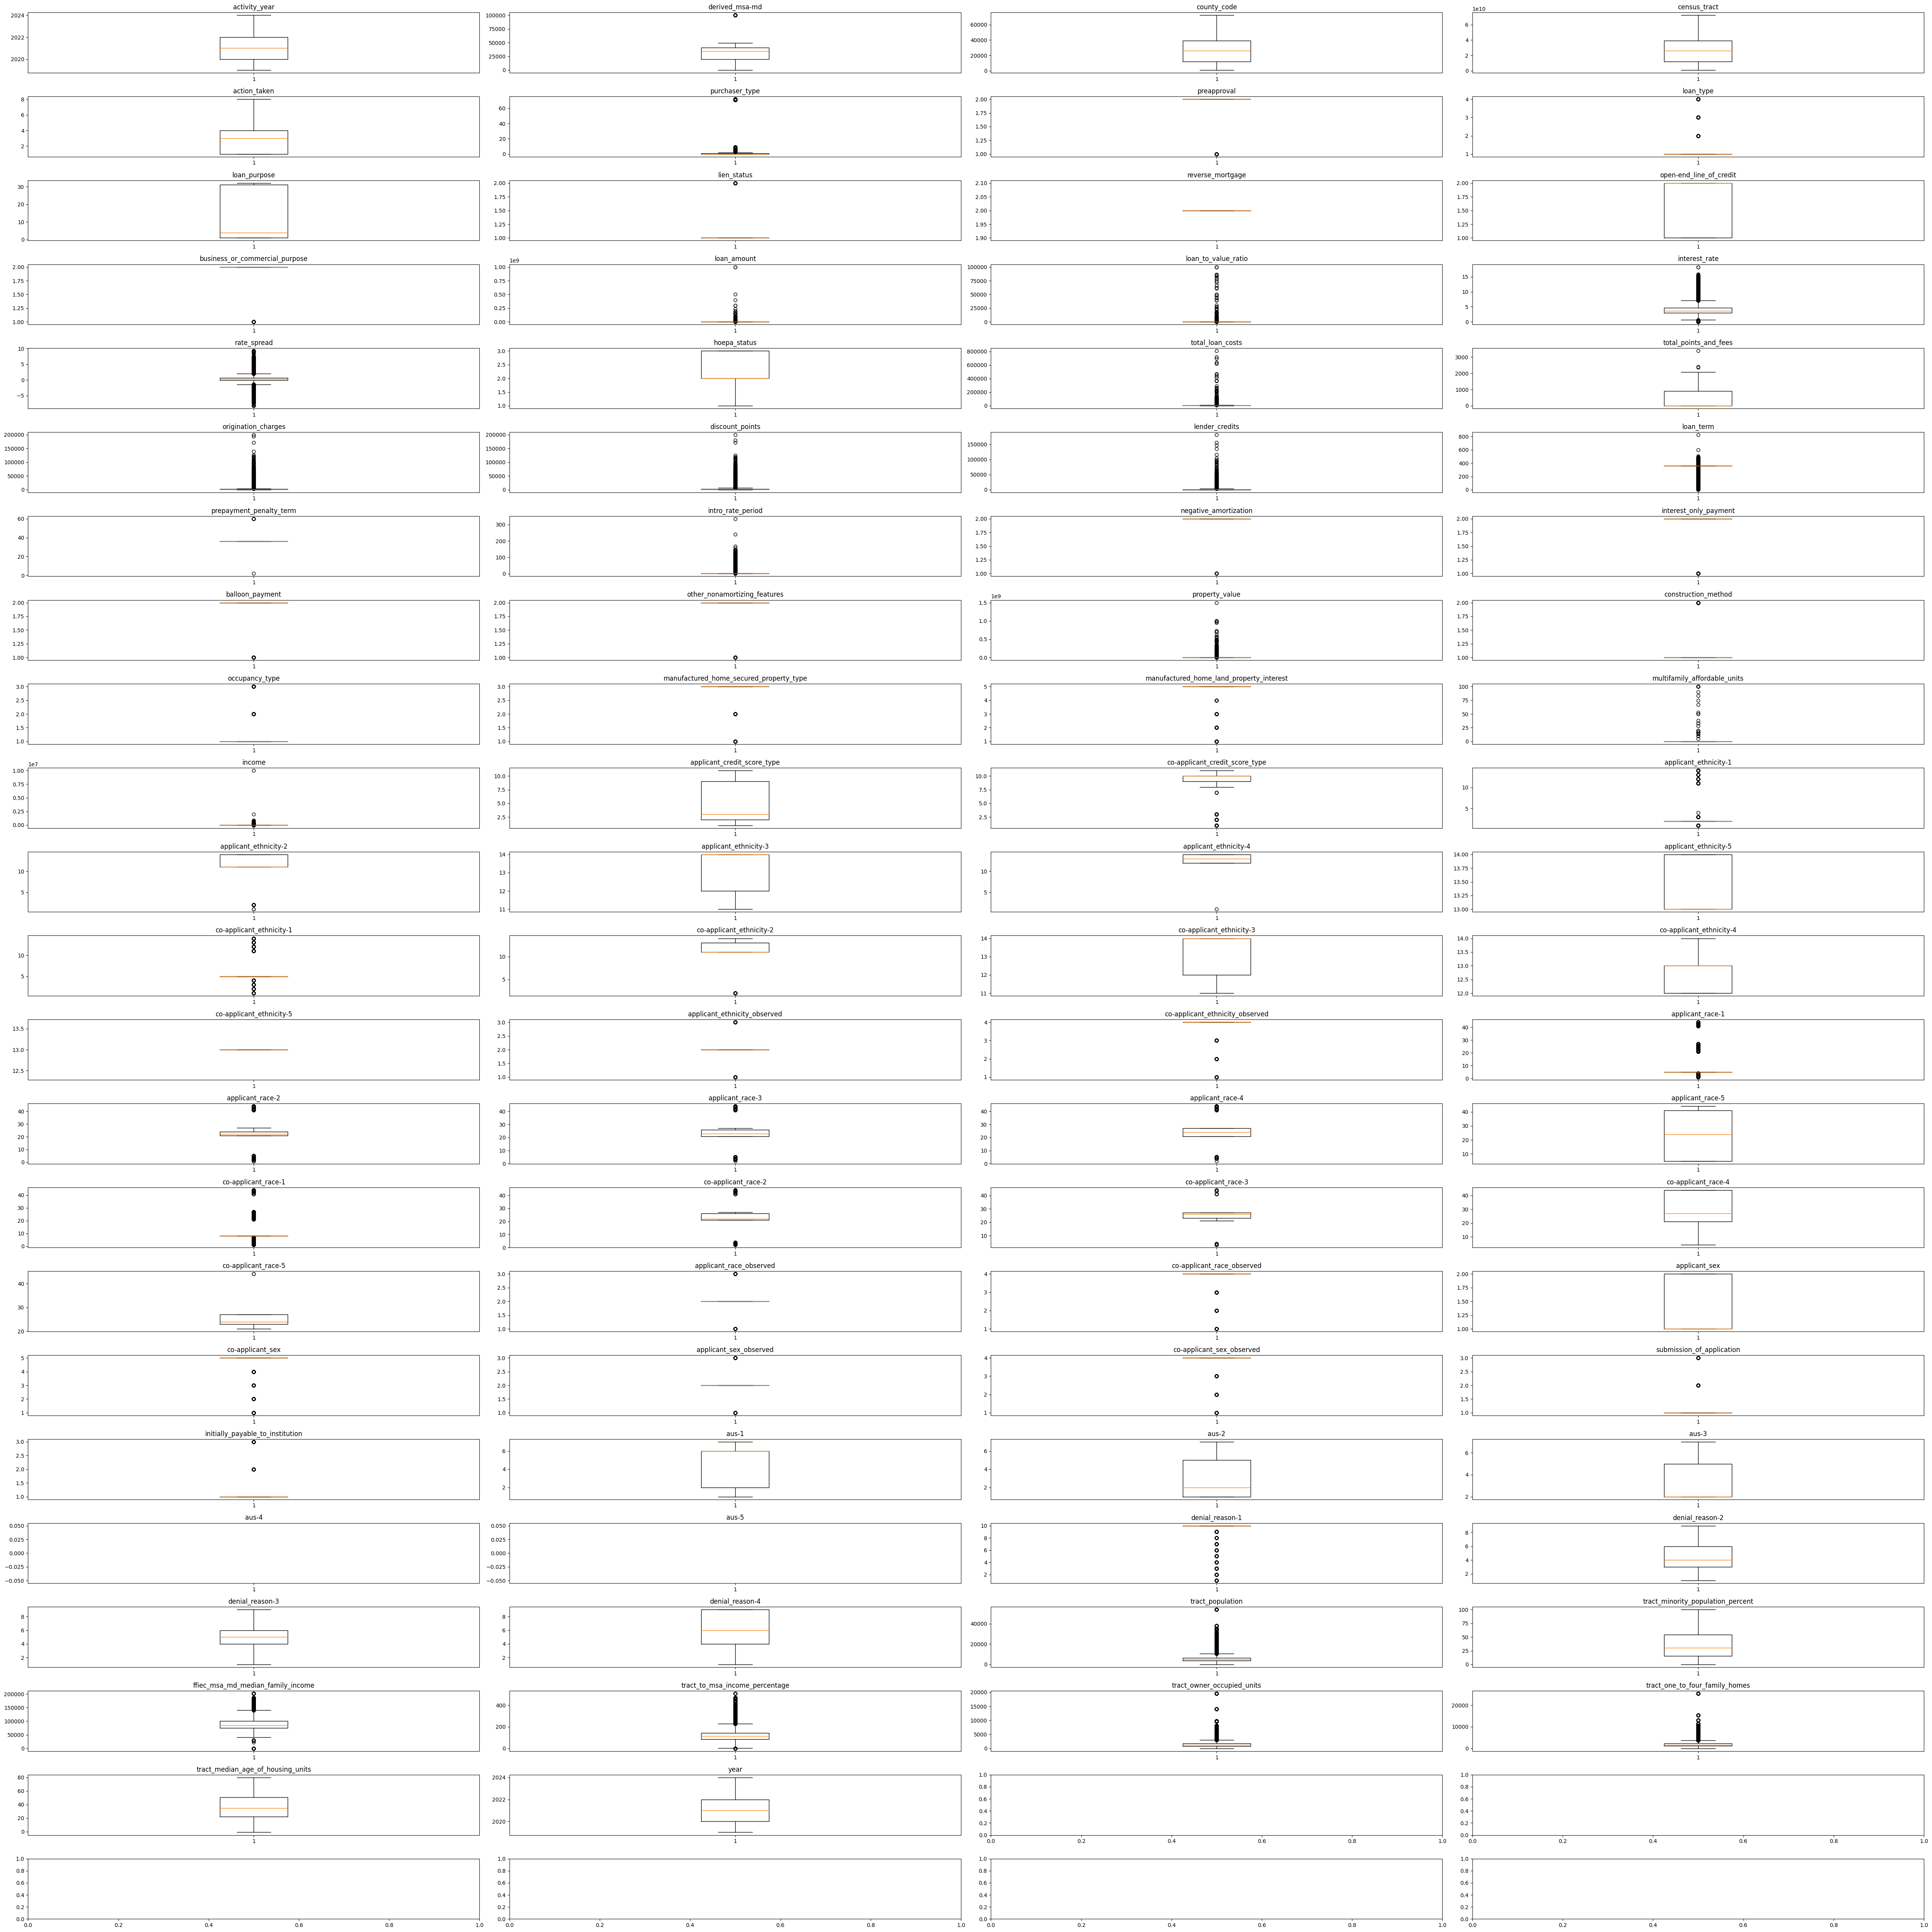

In [20]:
numeric_columns = df.select_dtypes(include='number').columns
 
fig, axes = plt.subplots(round(len(numeric_columns)/4)+1, 4, figsize=(50, 50))
axes = axes.flatten()
 
for i in range(len(numeric_columns)):
    axes[i].boxplot(df[numeric_columns[i]].dropna())
    axes[i].set_title(numeric_columns[i])
 
plt.tight_layout()
plt.show()


## 7. Correlaciones


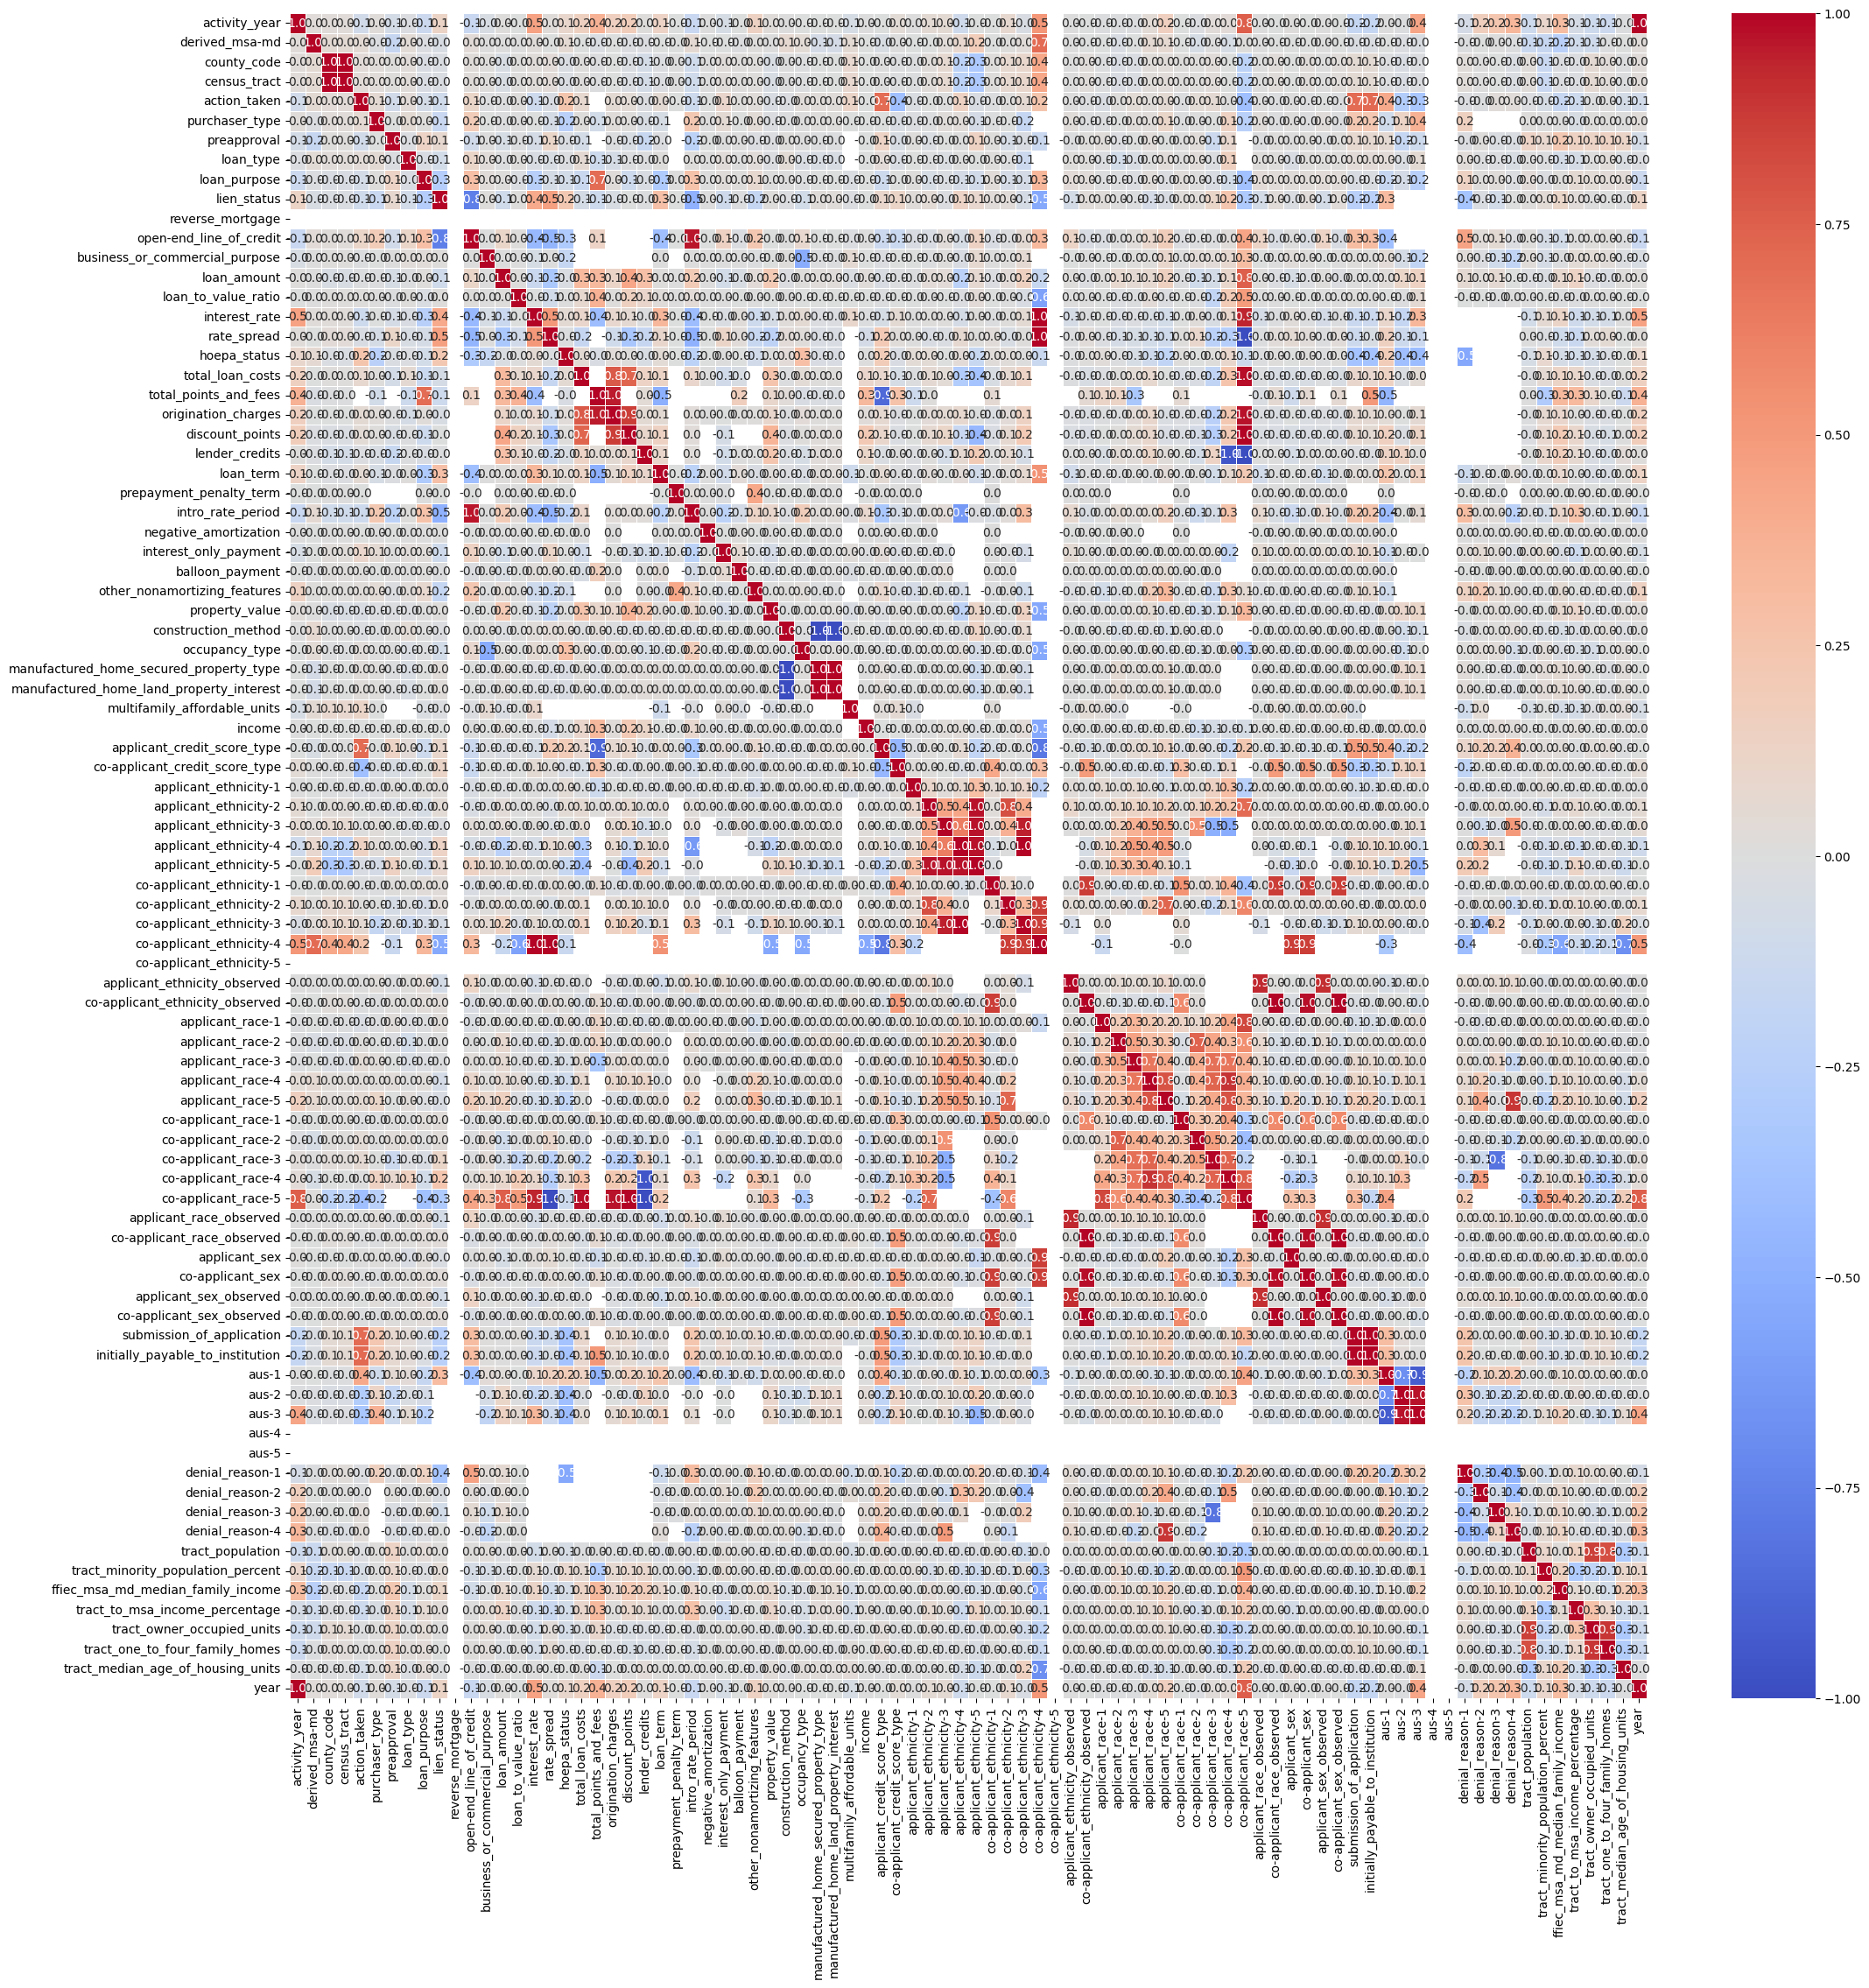

In [21]:
numeric_columns = df.select_dtypes(include='number').columns
df_numeric = df[numeric_columns]
correlation = df_numeric.corr()
 
plt.figure(figsize=(25, 25))
sns.heatmap(correlation,annot=True,fmt='.1f',cmap='coolwarm',center=0,linewidths=0.5)
plt.show()


## 2. Preparación del conjunto de modelización


Con las salidas anteriores más un análisis cualitativo de las variables se decide a priori dejar unicamnente estas variables, aunque no es el df definitivo.


In [22]:
keep_cols = [
    "activity_year",
    "state_code",
    "conforming_loan_limit",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "action_taken",
    "preapproval",
    "loan_type",
    "loan_purpose",
    "lien_status",
    "reverse_mortgage",
    "open-end_line_of_credit",
    "business_or_commercial_purpose",
    "loan_amount",
    "loan_to_value_ratio",
    "interest_rate",
    "rate_spread",
    "hoepa_status",
    "loan_term",
    "balloon_payment",
    "property_value",
    "construction_method",
    "occupancy_type",
    "total_units",
    "income",
    "debt_to_income_ratio",
    "applicant_ethnicity-1",
    "applicant_ethnicity-2",
    "co-applicant_ethnicity-1",
    "applicant_race-1",
    "applicant_race-2",
    "co-applicant_race-1",
    "applicant_sex",
    'co-applicant_sex',
    "applicant_sex_observed",
    "applicant_age",
    "co-applicant_age",
    "applicant_age_above_62",
    "co-applicant_age_above_62",
    "aus-1",
    "aus-2",
    "denial_reason-1",
    "denial_reason-2",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_median_age_of_housing_units",
    "year"
]

df_model = df[keep_cols]


In [23]:
df_model['business_or_commercial_purpose']


0          2
1          2
2          2
3          2
4          2
          ..
4363596    2
4363597    2
4363598    2
4363599    2
4363600    2
Name: business_or_commercial_purpose, Length: 4363601, dtype: int64

In [24]:
df_model['business_or_commercial_purpose'].value_counts()


business_or_commercial_purpose
2    4258643
1     104958
Name: count, dtype: int64

Analizamos la variable de razón de compra y dejamos unicamente las que son relacionadas con vivienda y no con negocio, ya que inversión no es nuestro objetivo. Y eliminamos las 79.968 que no son primera residencia


In [25]:
df_model=df_model[df_model['business_or_commercial_purpose']==2]


In [26]:
df_model['business_or_commercial_purpose'].value_counts()


business_or_commercial_purpose
2    4258643
Name: count, dtype: int64

In [27]:
df_model['denial_reason-1'].value_counts()


denial_reason-1
10    3251839
1      352481
3      341032
4      109857
9      103158
7       48717
6       27799
5       16505
2        7182
8          73
Name: count, dtype: int64

In [28]:
df_model.shape


(4258643, 51)

### Variable objetivo


In [29]:
df_model = df_model[df_model['action_taken'].isin([1,2,3])] # se cogen las 3 primeras de action_taken


df_model['target'] = df_model['action_taken'].map({ # se crea target a partir de action_taken
    1: 1,   # aprobado/originado
    2: 1,   # aprobado pero no aceptado
    3: 0    # denegado
})

# se elimina la variable action_taken, ya que la hemos sustituido
df_model.drop(columns=['action_taken'], inplace=True)


La variable action_taken se utiliza para construir la variable objetivo binaria (target), donde 1 indica concesión del crédito y 0 denegación. Posteriormente, la variable original se elimina del conjunto de variables explicativas para evitar filtraciones de información en el entrenamiento del modelo.


In [30]:
df_model['target'].value_counts()


target
1    1752497
0     991511
Name: count, dtype: int64

In [31]:
list(df_model.columns)


['activity_year',
 'state_code',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open-end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'loan_term',
 'balloon_payment',
 'property_value',
 'construction_method',
 'occupancy_type',
 'total_units',
 'income',
 'debt_to_income_ratio',
 'applicant_ethnicity-1',
 'applicant_ethnicity-2',
 'co-applicant_ethnicity-1',
 'applicant_race-1',
 'applicant_race-2',
 'co-applicant_race-1',
 'applicant_sex',
 'co-applicant_sex',
 'applicant_sex_observed',
 'applicant_age',
 'co-applicant_age',
 'applicant_age_above_62',
 'co-applicant_age_above_62',
 'aus-1',
 'aus-2',
 'denial_reason-1',
 'denial_reason-2',
 'ffiec_msa_md_median_family_income',
 'tract_to_msa_income_percentage'

## 2. Estadísticos descriptivos


In [32]:
df_model.describe()


,activity_year,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,...,aus-1,aus-2,denial_reason-1,denial_reason-2,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_median_age_of_housing_units,year,target
count,2.744008e+06,2.744008e+06,2.744008e+06,2.744008e+06,2.744008e+06,2744008.0,2.744008e+06,2744008.0,2.744008e+06,2.643256e+06,...,2.744008e+06,768857.000000,2.744008e+06,290832.000000,2.744008e+06,2.744008e+06,2.744008e+06,2.744008e+06,2.744008e+06,2.744008e+06
mean,2.020903e+03,1.983095e+00,1.038438e+00,1.406560e+01,1.256887e+00,2.0,1.636201e+00,2.0,2.870866e+05,6.655913e+01,...,4.109730e+00,3.487770,7.590977e+00,4.451236,9.067861e+04,1.214449e+02,1.357258e+03,3.739815e+01,2.020903e+03,6.386632e-01
std,1.560501e+00,1.289150e-01,2.525024e-01,1.445984e+01,4.369164e-01,0.0,4.810917e-01,0.0,9.043140e+05,2.176566e+02,...,2.280805e+00,2.057777,3.534075e+00,2.655294,2.202519e+04,5.135111e+01,8.167834e+02,1.894427e+01,1.560501e+00,4.803880e-01
min,2.019000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.0,1.000000e+00,2.0,5.000000e+03,5.000000e-03,...,1.000000e+00,1.000000,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.019000e+03,0.000000e+00
25%,2.020000e+03,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.0,1.000000e+00,2.0,8.500000e+04,5.026000e+01,...,1.000000e+00,1.000000,3.000000e+00,3.000000,7.540000e+04,8.747000e+01,8.550000e+02,2.300000e+01,2.020000e+03,0.000000e+00
50%,2.021000e+03,2.000000e+00,1.000000e+00,4.000000e+00,1.000000e+00,2.0,2.000000e+00,2.0,1.750000e+05,6.993000e+01,...,5.000000e+00,5.000000,1.000000e+01,4.000000,8.550000e+04,1.127800e+02,1.240000e+03,3.600000e+01,2.021000e+03,1.000000e+00
75%,2.022000e+03,2.000000e+00,1.000000e+00,3.100000e+01,2.000000e+00,2.0,2.000000e+00,2.0,3.150000e+05,8.000000e+01,...,6.000000e+00,5.000000,1.000000e+01,6.000000,1.019000e+05,1.450000e+02,1.692000e+03,5.100000e+01,2.022000e+03,1.000000e+00
max,2.024000e+03,2.000000e+00,4.000000e+00,3.200000e+01,2.000000e+00,2.0,2.000000e+00,2.0,9.999950e+08,1.000000e+05,...,7.000000e+00,7.000000,1.000000e+01,9.000000,2.013000e+05,5.074700e+02,1.952900e+04,8.000000e+01,2.024000e+03,1.000000e+00


## 3.Variables categóricas


In [33]:
df_model.describe(include='object') # categórias


C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\3601676002.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.describe(include='object') # categórias


,state_code,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,total_units,debt_to_income_ratio,applicant_age,co-applicant_age,applicant_age_above_62,co-applicant_age_above_62
count,2743872,2743995,2744008,2744008,2744008,2744008,2744008,2744008,2653967,2744008,2744008,2743960,109275
unique,52,3,7,3,5,6,2,9,19,8,10,2,2
top,CA,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,1,20%-<30%,45-54,9999,No,No
freq,427053,2503375,1968402,2721111,2300957,2029820,1643406,2474903,479756,680251,2633209,2157783,80167


In [34]:
df_model.select_dtypes(include='object').nunique()


C:\Users\jgilsanzmu001\AppData\Local\Temp\ipykernel_2496\877806476.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.select_dtypes(include='object').nunique()


state_code                   52
conforming_loan_limit         3
derived_loan_product_type     7
derived_dwelling_category     3
derived_ethnicity             5
derived_race                  6
derived_sex                   2
total_units                   9
debt_to_income_ratio         19
applicant_age                 8
co-applicant_age             10
applicant_age_above_62        2
co-applicant_age_above_62     2
dtype: int64

## 4. Variables numéricas


In [35]:
df_model.select_dtypes(include='number').columns


Index(['activity_year', 'preapproval', 'loan_type', 'loan_purpose',
       'lien_status', 'reverse_mortgage', 'open-end_line_of_credit',
       'business_or_commercial_purpose', 'loan_amount', 'loan_to_value_ratio',
       'interest_rate', 'rate_spread', 'hoepa_status', 'loan_term',
       'balloon_payment', 'property_value', 'construction_method',
       'occupancy_type', 'income', 'applicant_ethnicity-1',
       'applicant_ethnicity-2', 'co-applicant_ethnicity-1', 'applicant_race-1',
       'applicant_race-2', 'co-applicant_race-1', 'applicant_sex',
       'co-applicant_sex', 'applicant_sex_observed', 'aus-1', 'aus-2',
       'denial_reason-1', 'denial_reason-2',
       'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage',
       'tract_owner_occupied_units', 'tract_median_age_of_housing_units',
       'year', 'target'],
      dtype='str')

## 5. Missings


In [36]:
df.isna().mean().sort_values(ascending=False)


aus-4                                1.000000
aus-5                                1.000000
co-applicant_ethnicity-5             1.000000
co-applicant_ethnicity-4             0.999999
co-applicant_race-5                  0.999998
                                       ...   
tract_to_msa_income_percentage       0.000000
tract_owner_occupied_units           0.000000
tract_one_to_four_family_homes       0.000000
tract_median_age_of_housing_units    0.000000
year                                 0.000000
Length: 100, dtype: float64

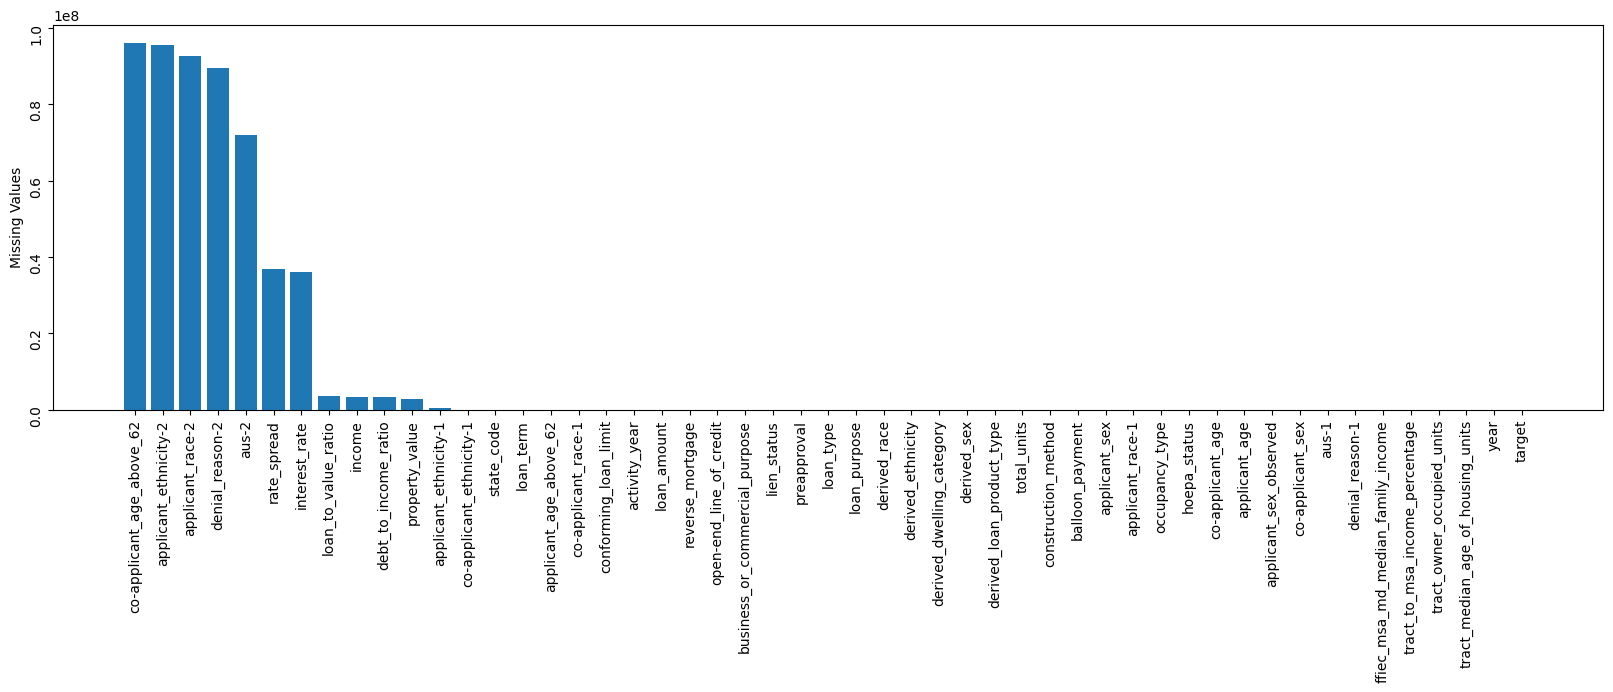

In [37]:
missing = df_model.isna().sum().sort_values(ascending=False)
missing_pct=missing/df_model.shape[0]*100

plt.figure(figsize=(20, 5))
plt.bar(missing_pct.index, missing_pct.values*1000000)
plt.xticks(rotation=90)
plt.ylabel("numero de missing por variable")
plt.ylabel('Missing Values')
plt.yticks(rotation=90)
plt.show()


In [38]:
cols_clave = ["state_code"]

df_model = df_model.dropna(subset=cols_clave)


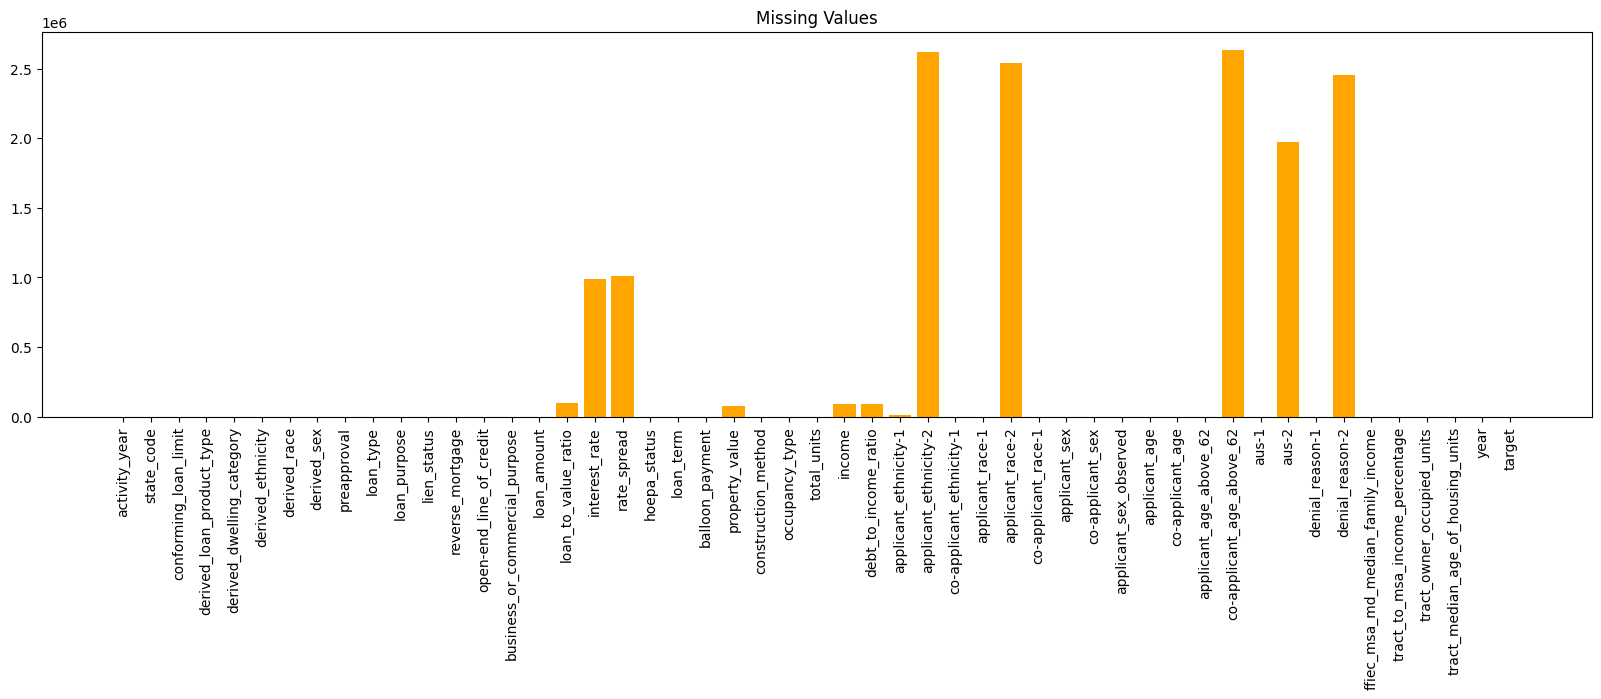

In [39]:
missing = list(df_model.isna().sum())

plt.figure(figsize=(20, 5))
plt.bar(df_model.columns, missing, color='orange')
plt.xticks(rotation=90)
plt.title('Missing Values')
plt.show()


## Estudio de variables con missings


In [40]:
# loan_to_value_ratio

df_model['loan_to_value_ratio'].dtypes
df_model['loan_to_value_ratio'].describe()


count    2.643120e+06
mean     6.655562e+01
std      2.176074e+02
min      5.000000e-03
25%      5.026000e+01
50%      6.993000e+01
75%      8.000000e+01
max      1.000000e+05
Name: loan_to_value_ratio, dtype: float64

In [41]:
# interest_rate

df_model['interest_rate'].dtypes
df_model['interest_rate'].describe()


count    1.752274e+06
mean     4.204538e+00
std      1.818859e+00
min      0.000000e+00
25%      2.875000e+00
50%      3.590000e+00
75%      5.088750e+00
max      1.825000e+01
Name: interest_rate, dtype: float64

In [42]:
# calcular la mediana solo en aprobados
median_tipo = df_model.loc[df_model['target'] == 1, 'interest_rate'].median()

# imputar missing solo en aprobados
df_model.loc[
    (df_model['target'] == 1) & (df_model['interest_rate'].isna()),
    'interest_rate'
] = median_tipo

# en denegados se pone 0
df_model.loc[df_model['target'] == 0, 'interest_rate'] = 0


In [43]:
#property_value

df_model['property_value'].dtypes
df_model['property_value'].describe()


count    2.668803e+06
mean     6.078117e+05
std      2.517328e+06
min      5.000000e+03
25%      2.450000e+05
50%      3.850000e+05
75%      6.650000e+05
max      1.500005e+09
Name: property_value, dtype: float64

In [44]:
num_cols = [
    "loan_to_value_ratio",
    'property_value']

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())


In [45]:
df_model['rate_spread'].dtypes
df_model['rate_spread'].describe()


count    1.733496e+06
mean     3.995746e-01
std      9.760111e-01
min     -8.220000e+00
25%     -1.250000e-01
50%      2.430000e-01
75%      7.181900e-01
max      9.250000e+00
Name: rate_spread, dtype: float64

In [46]:
#Dado que una parte relevante de los valores ausentes puede ser estructural (no aplicable o no reportado), se crea una variable indicadora de missing para que el modelo pueda diferenciar entre ausencia de información y valor real. Posteriormente, los NaN se imputan con 0 únicamente para permitir el entrenamiento del modelo sin perder esa distinción.
df_model["rate_spread_missing"] = df_model["rate_spread"].isna().astype(int)
df_model["rate_spread"] = df_model["rate_spread"].fillna(0)


In [47]:
df_model['income'].dtypes
df_model['income'].describe()


count    2.653413e+06
mean     1.579893e+02
std      6.280132e+03
min     -4.637800e+04
25%      5.500000e+01
50%      8.900000e+01
75%      1.520000e+02
max      1.000000e+07
Name: income, dtype: float64

In [48]:
# Convertir valores negativos en NaN ya que no tiene sentido un income negativo para posteriormente imputarlos con la mediana. 

df_model.loc[df_model["income"] < 0, "income"] = np.nan
df_model["income"] = df_model["income"].fillna(0)


In [49]:
#debt_to_income_ratio 

df_model['debt_to_income_ratio'].dtypes
df_model['debt_to_income_ratio'].describe()


count      2653832
unique          19
top       20%-<30%
freq        479740
Name: debt_to_income_ratio, dtype: object

In [50]:
df_model["debt_to_income_ratio"] = df_model["debt_to_income_ratio"].fillna("Unknown")


In [51]:
#applicant_ethnicity-2 

df_model['applicant_ethnicity-2'].dtypes
df_model['applicant_ethnicity-2'].describe()


count    126270.000000
mean         11.926459
std           1.841770
min           1.000000
25%          11.000000
50%          11.000000
75%          14.000000
max          14.000000
Name: applicant_ethnicity-2, dtype: float64

In [52]:
df_model['applicant_ethnicity-2'].value_counts()


applicant_ethnicity-2
11.0    66353
14.0    33694
12.0    12727
13.0    11331
2.0      2163
1.0         2
Name: count, dtype: int64

In [53]:
# La eliminamos para evitar introducir ruido y redundancia en el modelo sin perder información relevante para el análisis de sesgos.

df_model = df_model.drop(columns=["applicant_ethnicity-2"])


In [54]:
# applicant_race-2

df_model['applicant_race-2'].dtypes
df_model['applicant_race-2'].describe()


count    201901.000000
mean         20.403401
std           7.597819
min           1.000000
25%          21.000000
50%          22.000000
75%          24.000000
max          44.000000
Name: applicant_race-2, dtype: float64

In [55]:
df_model['applicant_race-2'].value_counts()


applicant_race-2
21.0    49113
22.0    48888
5.0     26259
23.0    17234
27.0    15909
26.0    15779
25.0    15019
24.0     4331
3.0      4307
44.0     2437
2.0       853
4.0       795
41.0      523
42.0      251
43.0      201
1.0         2
Name: count, dtype: int64

La variable applicant_race-2, correspondiente a la segunda raza declarada por el solicitante, presenta el 99% de los valores observados pertenecen a una única categoría y el porcentaje de valores ausentes es extremadamente elevado. Dada su escasa capacidad informativa y su carácter secundario respecto a la variable principal de raza, se decide eliminarla del análisis para evitar introducir ruido y redundancia en el modelo.


In [56]:
df_model = df_model.drop(columns=["applicant_race-2"])


In [57]:
# co-applicant_age_above_62

df_model['co-applicant_age_above_62'].dtypes
df_model['co-applicant_age_above_62'].describe()


count     109271
unique         2
top           No
freq       80163
Name: co-applicant_age_above_62, dtype: object

In [58]:
df_model['co-applicant_age_above_62'].value_counts()


co-applicant_age_above_62
No     80163
Yes    29108
Name: count, dtype: int64

La variable relativa a la edad del cotitular presenta una proporción muy elevada de valores ausentes, en gran parte porque muchas operaciones no cuentan con cotitular. Se considera, por tanto, un caso de ausencia estructural y se crea una categoría específica para identificarlo.


In [59]:
df_model["co-applicant_age_above_62"] = df_model["co-applicant_age_above_62"].fillna("No co-applicant")


In [60]:
df_model['co-applicant_age_above_62'].value_counts()


co-applicant_age_above_62
No co-applicant    2634601
No                   80163
Yes                  29108
Name: count, dtype: int64

In [61]:
# aus-2

df_model['aus-2'].dtypes
df_model['aus-2'].describe()


count    768791.000000
mean          3.487958
std           2.057751
min           1.000000
25%           1.000000
50%           5.000000
75%           5.000000
max           7.000000
Name: aus-2, dtype: float64

In [62]:
df_model['aus-2'].value_counts()


aus-2
5.0    333402
1.0    206367
2.0    159004
7.0     70018
Name: count, dtype: int64

Dado su carácter secundario y el elevado porcentaje de valores ausentes, se decide excluirla del modelo para mantener el enfoque en variables individuales relevantes para el análisis de sesgos.


In [63]:
df_model = df_model.drop(columns=["aus-2"])


In [64]:
# denial_reason-2

df_model['denial_reason-2'].dtypes
df_model['denial_reason-2'].describe()


count    290782.000000
mean          4.451025
std           2.655229
min           1.000000
25%           3.000000
50%           4.000000
75%           6.000000
max           9.000000
Name: denial_reason-2, dtype: float64

In [65]:
df_model['denial_reason-2'].value_counts()


denial_reason-2
3.0    62149
4.0    57429
9.0    54937
1.0    53002
6.0    34359
5.0    20693
2.0     7320
7.0      723
8.0      170
Name: count, dtype: int64

In [66]:
df_model = df_model.drop(columns=["denial_reason-2"])


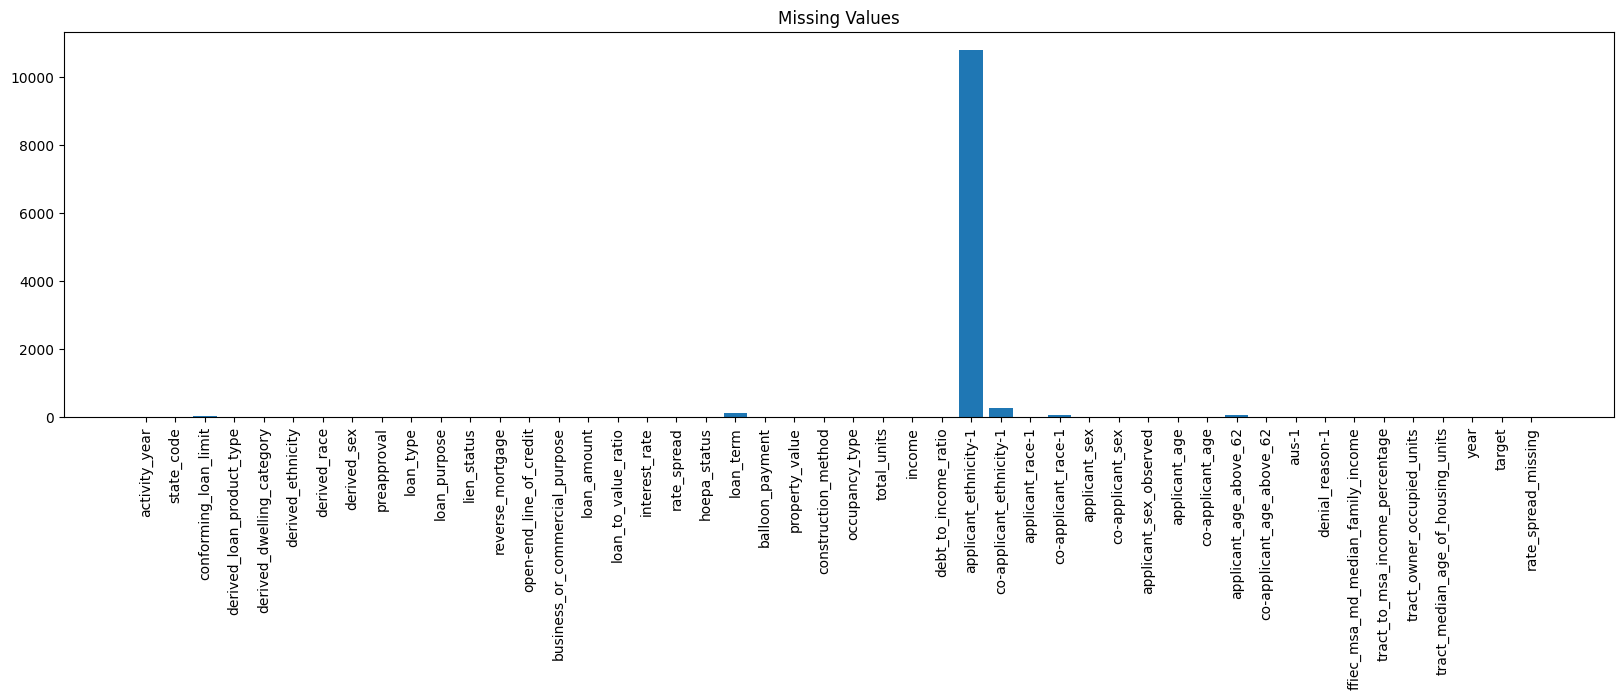

In [67]:
missing = list(df_model.isna().sum())

plt.figure(figsize=(20, 5))
plt.bar(df_model.columns, missing)
plt.xticks(rotation=90)
plt.title('Missing Values')
plt.show()


In [68]:
df_model['debt_to_income_ratio'].dtypes
df_model['debt_to_income_ratio'].describe()


count      2743872
unique          20
top       20%-<30%
freq        479740
Name: debt_to_income_ratio, dtype: object

In [69]:
df_model['debt_to_income_ratio'].value_counts()


debt_to_income_ratio
20%-<30%    479740
30%-<36%    403232
>60%        313251
<20%        227087
50%-60%     192450
42          100850
Unknown      90040
44           88515
41           85478
40           81934
39           80918
38           77637
43           76203
49           76157
37           75494
36           73444
45           59331
48           56339
47           53354
46           52418
Name: count, dtype: int64

La variable debt_to_income_ratio presenta una codificación mixta, ya que combina rangos porcentuales con valores numéricos exactos. Para mantener su interpretación económica y evitar generar un número excesivo de categorías, se transforma en una variable numérica continua asignando a cada rango un valor representativo (punto medio). De esta forma, se conserva el orden natural del ratio y se facilita su uso en el modelo. Los valores ausentes se imputan posteriormente mediante la mediana.


In [70]:
def clean_dti(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).replace("%", "").strip()

    if x == "<20":
        return 10
    elif x == "20-<30":
        return 25
    elif x == "30-<36":
        return 33
    elif x == "50-60":
        return 55
    elif x == ">60":
        return 65
    elif x.lower() == "unknown":
        return np.nan
    else:
        return float(x)

df_model["debt_to_income_ratio"] = df_model["debt_to_income_ratio"].apply(clean_dti)


In [71]:
df_model["debt_to_income_ratio"] = df_model["debt_to_income_ratio"].fillna(
    df_model["debt_to_income_ratio"].median()
)


In [72]:
df_model['applicant_ethnicity-1'].dtypes
df_model['applicant_ethnicity-1'].describe()


count    2.733083e+06
mean     2.178475e+00
std      1.707866e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      1.400000e+01
Name: applicant_ethnicity-1, dtype: float64

In [73]:
df_model['applicant_ethnicity-1'].value_counts()


applicant_ethnicity-1
2.0     2310112
1.0      287648
3.0       69615
14.0      32232
11.0      21386
12.0       6418
13.0       5671
4.0           1
Name: count, dtype: int64

In [74]:
df_model["applicant_ethnicity-1"] = df_model["applicant_ethnicity-1"].astype("category") # se puede usar como variable sensible para fairness


In [75]:
df_model["applicant_ethnicity-1"] = (
    df_model["applicant_ethnicity-1"]
    .cat.add_categories("Unknown") # se añade categoria unknown
    .fillna("Unknown") # se rellena con unknown
)


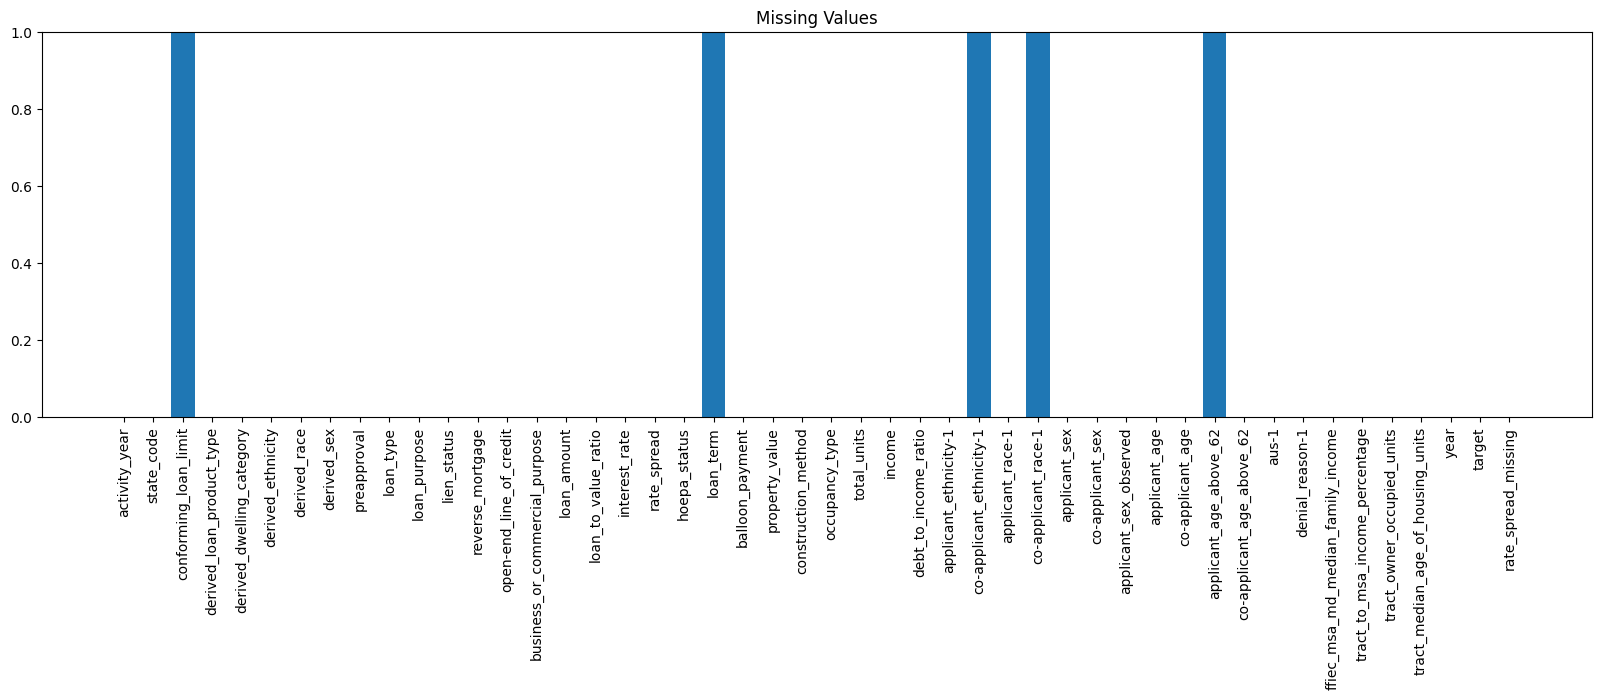

In [76]:
missing = list(df_model.isna().sum())

plt.figure(figsize=(20, 5))
plt.bar(df_model.columns, missing)
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.title('Missing Values')
plt.show()


In [77]:
df_model['conforming_loan_limit'].dtypes
df_model['conforming_loan_limit'].describe()


count     2743859
unique          2
top             C
freq      2503252
Name: conforming_loan_limit, dtype: object

In [78]:
df_model['conforming_loan_limit'].value_counts


<bound method IndexOpsMixin.value_counts of 0           C
22          C
23         NC
24          C
26          C
           ..
4362589    NC
4362590    NC
4362591    NC
4362593    NC
4362596     C
Name: conforming_loan_limit, Length: 2743872, dtype: str>

Los valores ausentes, que representan menos del 1% del total, se recodifican como una categoría adicional (“Unknown”) con el fin de preservar el tamaño muestral y evitar la pérdida de información.


In [79]:
df_model["conforming_loan_limit"] = (
    df_model["conforming_loan_limit"]
    .astype("category")
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)


In [80]:
#comprobación 3 categorias 

df_model['conforming_loan_limit'].value_counts


<bound method IndexOpsMixin.value_counts of 0           C
22          C
23         NC
24          C
26          C
           ..
4362589    NC
4362590    NC
4362591    NC
4362593    NC
4362596     C
Name: conforming_loan_limit, Length: 2743872, dtype: category
Categories (3, str): ['C', 'NC', 'Unknown']>

In [81]:
df_model['loan_term'].dtypes
df_model['loan_term'].describe()


count    2.743754e+06
mean     3.419379e+02
std      7.612660e+01
min      2.000000e+00
25%      3.600000e+02
50%      3.600000e+02
75%      3.600000e+02
max      5.960000e+02
Name: loan_term, dtype: float64

In [82]:
df_model['loan_term'].value_counts()


loan_term
360.0    1931592
180.0     276015
480.0     218709
361.0     124110
240.0      99922
          ...   
495.0          1
506.0          1
413.0          1
483.0          1
438.0          1
Name: count, Length: 475, dtype: int64

In [83]:
df_model['loan_term']=df_model['loan_term'].fillna(df_model['loan_term'].median())


In [84]:
df_model['co-applicant_ethnicity-1'].dtypes
df_model['co-applicant_ethnicity-1'].describe()


count    2.743611e+06
mean     4.888699e+00
std      6.382745e-01
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      1.400000e+01
Name: co-applicant_ethnicity-1, dtype: float64

In [85]:
df_model['co-applicant_ethnicity-1'].value_counts()


co-applicant_ethnicity-1
5.0     2633104
2.0       82542
1.0       13637
3.0       10321
4.0        1501
14.0       1033
11.0        942
13.0        284
12.0        247
Name: count, dtype: int64

In [86]:
# se convierte en categoria 

df_model["co-applicant_ethnicity-1"] = df_model["co-applicant_ethnicity-1"].astype("category")


In [87]:
df_model["co-applicant_ethnicity-1"] = (
    df_model["co-applicant_ethnicity-1"]
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)


In [88]:
df_model['co-applicant_race-1'].dtypes
df_model['co-applicant_race-1'].describe()


count    2.743836e+06
mean     7.895867e+00
std      9.435288e-01
min      1.000000e+00
25%      8.000000e+00
50%      8.000000e+00
75%      8.000000e+00
max      4.400000e+01
Name: co-applicant_race-1, dtype: float64

In [89]:
df_model['co-applicant_race-1'].value_counts()


co-applicant_race-1
8.0     2633104
5.0       78902
2.0        9977
6.0        9233
3.0        6323
21.0       1566
7.0        1500
22.0        741
23.0        592
1.0         504
27.0        435
26.0        351
44.0        209
25.0        182
4.0         139
24.0         53
42.0         10
41.0          8
43.0          7
Name: count, dtype: int64

In [90]:
#aunque sean pocos es -1%, es una variable sensible

df_model["co-applicant_race-1"] = (
    df_model["co-applicant_race-1"]
    .astype("category")
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)


In [91]:
df_model['applicant_age_above_62'].dtypes
df_model['applicant_age_above_62'].describe()


count     2743824
unique          2
top            No
freq      2157666
Name: applicant_age_above_62, dtype: object

In [92]:
df_model['applicant_age_above_62'].value_counts()


applicant_age_above_62
No     2157666
Yes     586158
Name: count, dtype: int64

In [93]:
df_model["applicant_age_above_62"] = (
    df_model["applicant_age_above_62"]
    .astype("category")
    .cat.add_categories("Unknown")
    .fillna("Unknown")
)


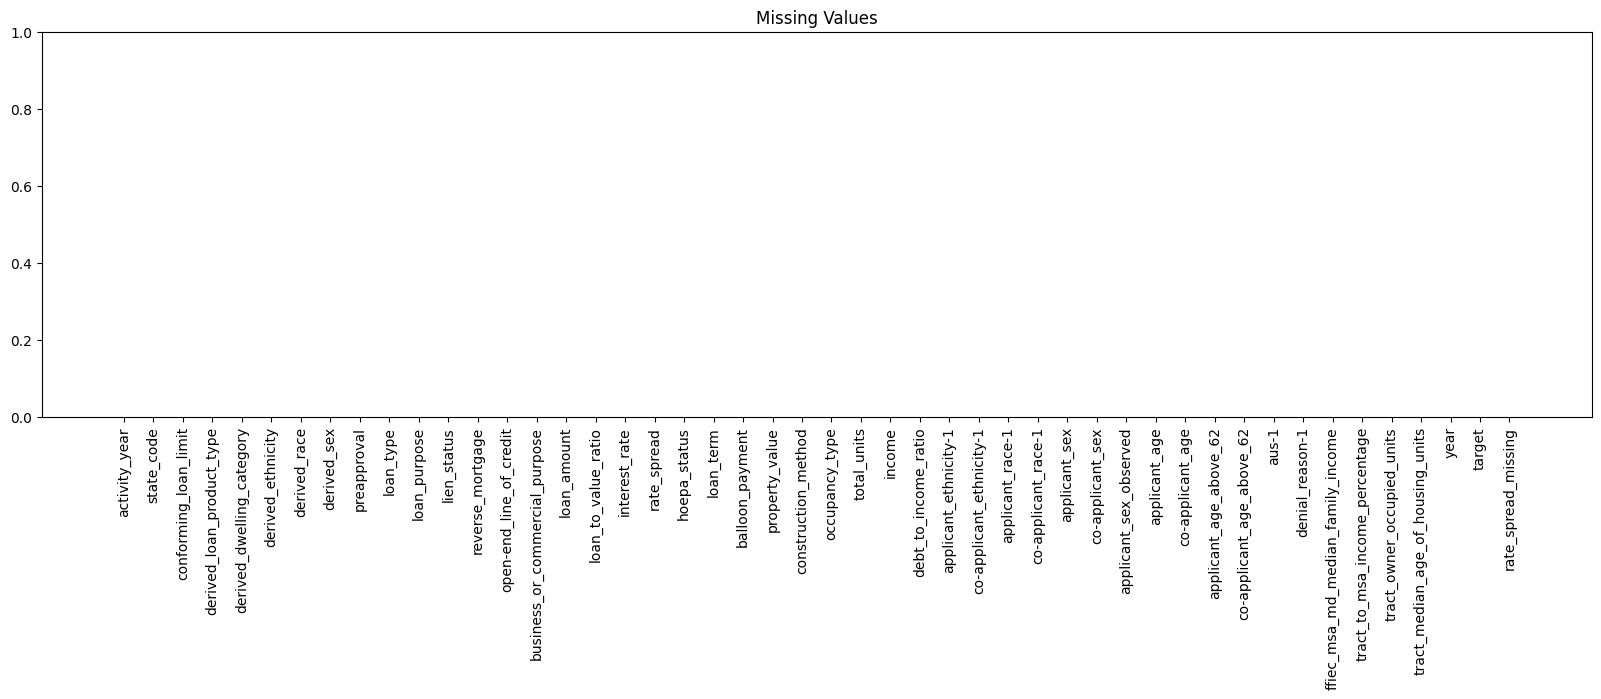

In [94]:
missing = list(df_model.isna().sum())

plt.figure(figsize=(20, 5))
plt.bar(df_model.columns, missing)
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.title('Missing Values')
plt.show()


In [95]:
df_model.isna().sum()


activity_year                        0
state_code                           0
conforming_loan_limit                0
derived_loan_product_type            0
derived_dwelling_category            0
derived_ethnicity                    0
derived_race                         0
derived_sex                          0
preapproval                          0
loan_type                            0
loan_purpose                         0
lien_status                          0
reverse_mortgage                     0
open-end_line_of_credit              0
business_or_commercial_purpose       0
loan_amount                          0
loan_to_value_ratio                  0
interest_rate                        0
rate_spread                          0
hoepa_status                         0
loan_term                            0
balloon_payment                      0
property_value                       0
construction_method                  0
occupancy_type                       0
total_units              

El df_model ya no tiene valores nulos, ahora se procede a tratar outliers


## 6.Outliers


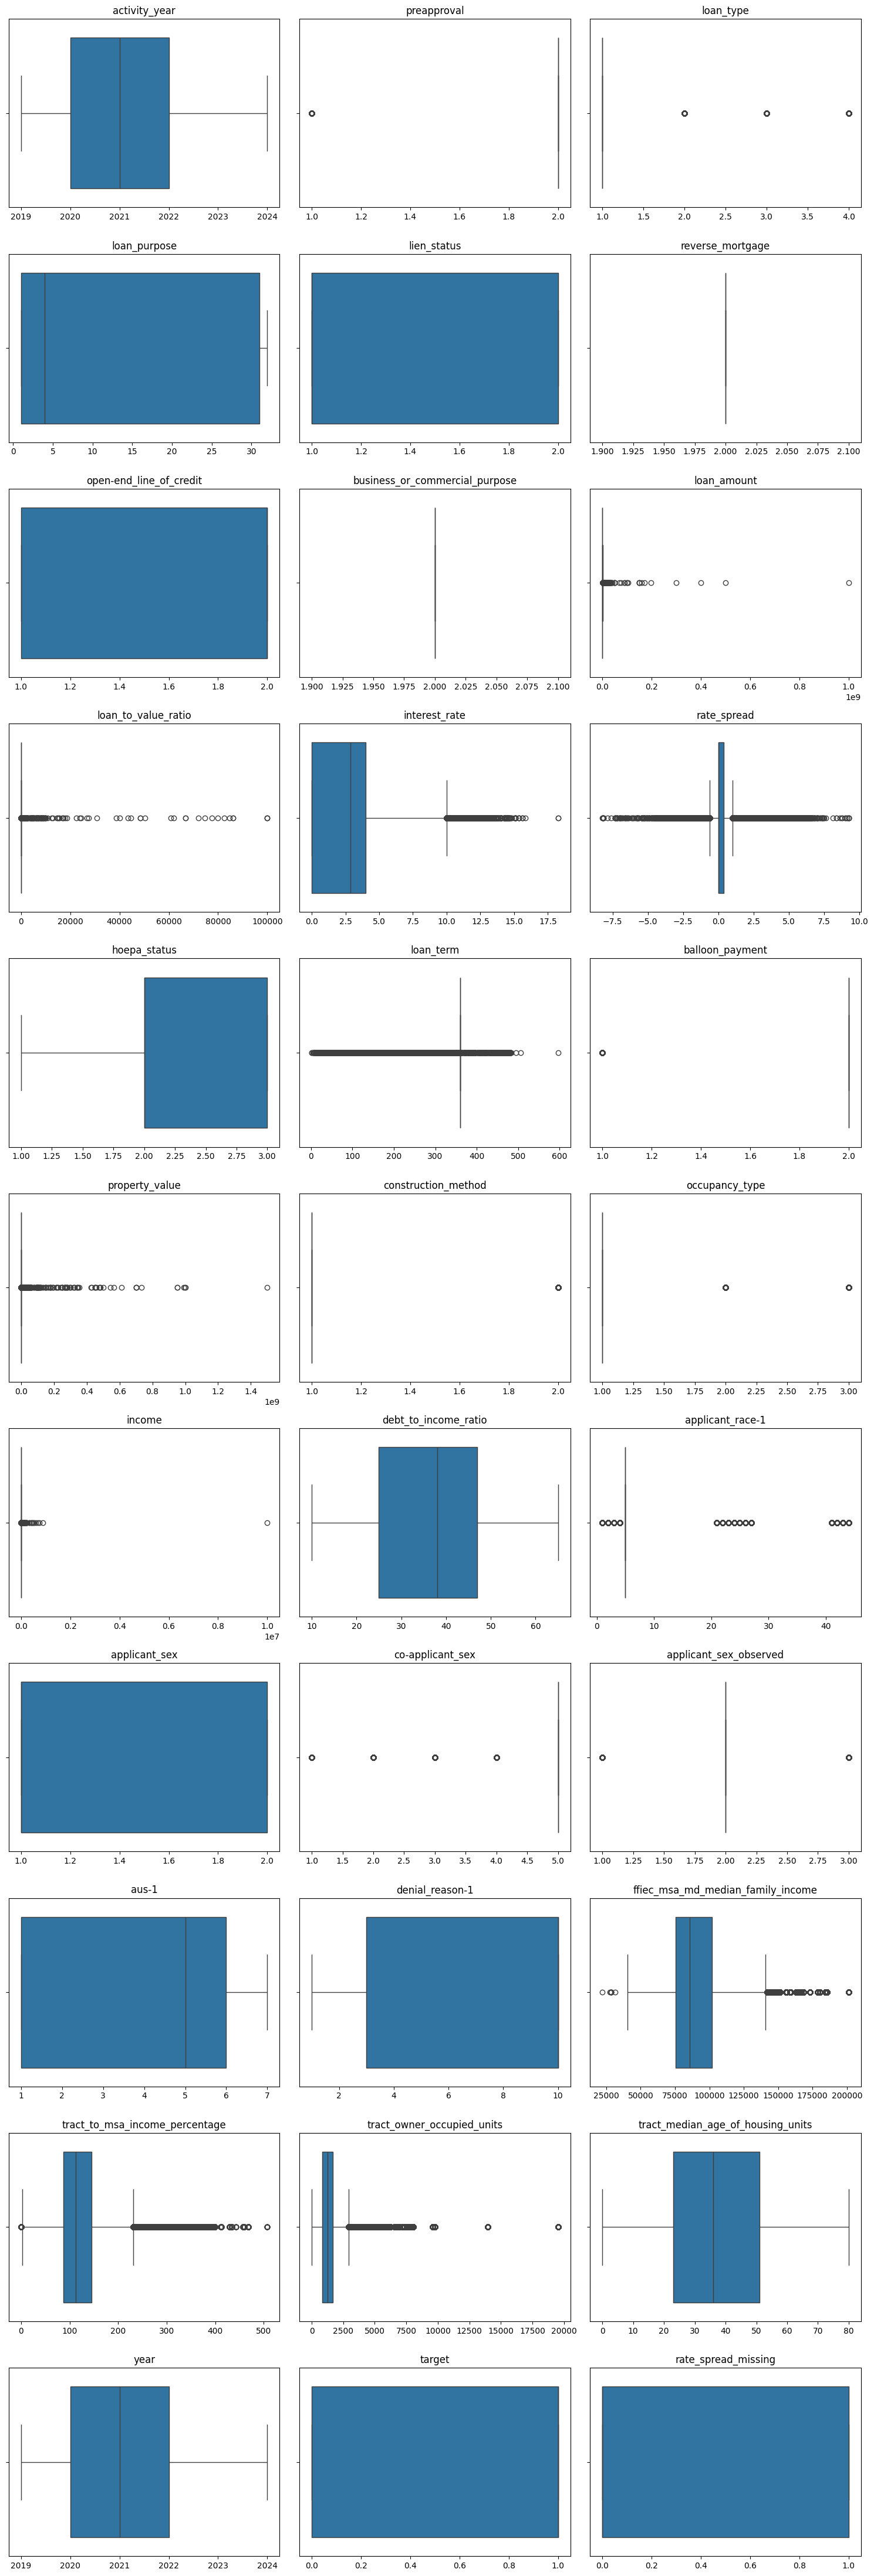

In [96]:
num_vars = df_model.select_dtypes(include=['int64','float64']).columns
num_vars


# quitar variables que no existan o que estén vacías
num_vars = [col for col in num_vars if col in df_model.columns]

n = len(num_vars)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.boxplot(x=df_model[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# borrar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [97]:
import pandas as pd

outlier_summary = []

for col in num_vars:
    s = df_model[col].dropna()
    
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((s < lower) | (s > upper)).sum()
    total = s.shape[0]
    pct_outliers = (outliers / total) * 100
    
    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": outliers,
        "%_outliers": round(pct_outliers, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("%_outliers", ascending=False)
outlier_summary


,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,%_outliers
13,loan_term,360.00,360.0,0.00,360.000,360.000,812162,29.60
20,applicant_race-1,5.00,5.0,0.00,5.000,5.000,706985,25.77
11,rate_spread,0.00,0.4,0.40,-0.600,1.000,438164,15.97
8,loan_amount,85000.00,315000.0,230000.00,-260000.000,660000.000,247975,9.04
15,property_value,245000.00,655000.0,410000.00,-370000.000,1270000.000,242808,8.85
18,income,52.00,150.0,98.00,-95.000,297.000,226829,8.27
17,occupancy_type,1.00,1.0,0.00,1.000,1.000,160705,5.86
22,co-applicant_sex,5.00,5.0,0.00,5.000,5.000,110766,4.04
27,tract_to_msa_income_percentage,87.48,145.0,57.52,1.200,231.280,107142,3.90
26,ffiec_msa_md_median_family_income,75400.00,101900.0,26500.00,35650.000,141650.000,88321,3.22


In [98]:
outlier_summary.shape


(33, 8)

- DE LAS 33, 14 están a 0% de outliers 

- de las 19 restantes, 

- 1. loan_term: no aplicar tratamiento de outliers
- 2. interest_rate: winsorizar
- 3. rate_spread: winsorizar
- 4. applicant_race-1: no aplicar tratamiento de outliers
- 5. property_value: log
- 6. income: log
- 7. loan_amount: log 
- 8. ocupancy_type: no aplicar tratamiento de outliers
- 9. co-applicant_sex: no aplicar tratamiento de outliers
- 10. tract_to_msa_income_percentage: revisar distribución; en principio dejarla o winsorizar ligeramente
- 11. tract_owner_occupied_units: winsorizar
- 12. ffiec_msa_md_median_family_income: no aplicar tratamiento de outliers
- 13. loan_type: no aplicar tratamiento de outliers
- 14. business_or_commercial_purpose: no aplicar tratamiento de outliers
- 15. applicant_sex_observed: no aplicar tratamiento de outliers
- 16. preapproval: no aplicar tratamiento de outliers
- 17. construction_method — no aplicar tratamiento de outliers

- 18. loan_to_value_ratio: Solo winsoriza si aparecen valores muy altos (ej. >200) o claramente erróneos.

- 19. balloon_payment — no aplicar tratamiento de outliers


## Winsorizar


In [99]:
winsor_vars = [
    'interest_rate',
    'rate_spread',
    'tract_owner_occupied_units'
]


In [100]:
for col in winsor_vars:
    lower = df_model[col].quantile(0.01)
    upper = df_model[col].quantile(0.99)
    
    df_model[col] = df_model[col].clip(lower, upper)


## log


In [101]:
log_vars = [
    'property_value',
    'income',
    'loan_amount'
]


In [102]:
for col in log_vars:
    df_model[col] = np.log1p(df_model[col])


## Revisar estas dos: 

- tract_to_msa_income_percentage
- loan_to_value_ratio


In [103]:
df_model['tract_to_msa_income_percentage'].describe()


count    2.743872e+06
mean     1.214507e+02
std      5.134554e+01
min      0.000000e+00
25%      8.748000e+01
50%      1.127900e+02
75%      1.450000e+02
max      5.074700e+02
Name: tract_to_msa_income_percentage, dtype: float64

La variable se conserva sin transformaciones adicionales.


In [104]:
df_model['loan_to_value_ratio'].describe()


count    2.743872e+06
mean     6.667953e+01
std      2.135758e+02
min      5.000000e-03
25%      5.125000e+01
50%      6.993000e+01
75%      8.000000e+01
max      1.000000e+05
Name: loan_to_value_ratio, dtype: float64

In [105]:
# capar en 200
df_model['loan_to_value_ratio'] = df_model['loan_to_value_ratio'].clip(upper=200)


## Comprobaciones


In [106]:
df_model.describe().T


,count,mean,std,min,25%,50%,75%,max
activity_year,2743872.0,2020.902821,1.560498,2019.000000,2020.000000,2021.000000,2022.000000,2024.000000
preapproval,2743872.0,1.983094,0.128918,1.000000,2.000000,2.000000,2.000000,2.000000
loan_type,2743872.0,1.038430,0.252467,1.000000,1.000000,1.000000,1.000000,4.000000
loan_purpose,2743872.0,14.065984,14.459878,1.000000,1.000000,4.000000,31.000000,32.000000
lien_status,2743872.0,1.256899,0.436924,1.000000,1.000000,1.000000,2.000000,2.000000
reverse_mortgage,2743872.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
open-end_line_of_credit,2743872.0,1.636183,0.481097,1.000000,1.000000,2.000000,2.000000,2.000000
business_or_commercial_purpose,2743872.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
loan_amount,2743872.0,12.039680,1.005133,8.517393,11.350418,12.072547,12.660331,20.723261
loan_to_value_ratio,2743872.0,65.385095,22.636378,0.005000,51.250000,69.930000,80.000000,200.000000


In [107]:
outlier_summary = []

for col in num_vars:
    
    s = df_model[col].dropna()
    
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((s < lower) | (s > upper)).sum()
    
    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": outliers,
        "%_outliers": outliers / len(s) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)


In [108]:
outlier_summary.sort_values("%_outliers", ascending=False)


,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,%_outliers
13,loan_term,360.000000,360.000000,0.000000,360.000000,360.000000,812162,29.599121
20,applicant_race-1,5.000000,5.000000,0.000000,5.000000,5.000000,706985,25.765961
11,rate_spread,0.000000,0.400000,0.400000,-0.600000,1.000000,438164,15.968821
18,income,3.970292,5.017280,1.046988,2.399810,6.587762,181685,6.621482
17,occupancy_type,1.000000,1.000000,0.000000,1.000000,1.000000,160705,5.856869
22,co-applicant_sex,5.000000,5.000000,0.000000,5.000000,5.000000,110766,4.036850
27,tract_to_msa_income_percentage,87.480000,145.000000,57.520000,1.200000,231.280000,107142,3.904774
26,ffiec_msa_md_median_family_income,75400.000000,101900.000000,26500.000000,35650.000000,141650.000000,88321,3.218845
28,tract_owner_occupied_units,855.000000,1692.000000,837.000000,-400.500000,2947.500000,85224,3.105976
2,loan_type,1.000000,1.000000,0.000000,1.000000,1.000000,70701,2.576687


Se detectaron valores extremos mediante el método IQR. Las variables categóricas codificadas numéricamente se excluyeron del tratamiento de outliers. Para variables continuas con distribuciones altamente asimétricas (income, loan_amount y property_value) se aplicó una transformación logarítmica. En otras variables con valores extremos plausibles se aplicó winsorización para limitar su impacto sin eliminar observaciones.


## Encoding


In [109]:
df_model['derived_sex'] = df_model['derived_sex'].replace({
    'Male': 'hombre',
    'Female': 'mujer'
})


In [110]:
df_model['derived_race'].value_counts()


derived_race
White                                        2029738
Asian                                         362539
Black or African American                     300793
American Indian or Alaska Native               28057
Native Hawaiian or Other Pacific Islander      13407
2 or more minority races                        9338
Name: count, dtype: int64

In [111]:
df_model['derived_race'] = df_model['derived_race'].replace({
    0: 'white',
    1: 'black',   
})


In [112]:
df_model['loan_term'].value_counts()


loan_term
360.0    1931710
180.0     276015
480.0     218709
361.0     124110
240.0      99922
          ...   
495.0          1
506.0          1
413.0          1
483.0          1
438.0          1
Name: count, Length: 475, dtype: int64

In [113]:
df_model['loan_term_years'] = (df_model['loan_term'] / 12).round(1)

df_model['loan_term_group'] = pd.cut(
    df_model['loan_term_years'],
    bins=[0,15,20,30,40,1000],
    labels=['≤15y','15-20y','20-30y','30-40y','>40y']
)


| grupo  | significado      |
| ------ | ---------------- |
| ≤15y   | préstamos cortos |
| 15–20y | plazo medio      |
| 20–30y | estándar         |
| 30–40y | largos           |
| >40y   | raros            |


In [114]:
df_model["business_or_commercial_purpose"]


0          2
22         2
23         2
24         2
26         2
          ..
4362589    2
4362590    2
4362591    2
4362593    2
4362596    2
Name: business_or_commercial_purpose, Length: 2743872, dtype: int64

## 2.8 Normalización de nombres


In [122]:
df['loan_amount'].sum()


np.float64(1290368035000.0)

In [115]:
df_model = df_model.rename(columns={

    'activity_year':'anio_actividad',
    'state_code':'codigo_estado',
    'conforming_loan_limit':'limite_prestamo_conforme',
    'derived_loan_product_type':'tipo_producto_prestamo',
    'derived_dwelling_category':'categoria_vivienda',
    'derived_ethnicity':'etnia',
    'derived_race':'raza',
    'derived_sex':'sexo',
    'preapproval':'preaprobacion',
    'loan_type':'tipo_prestamo',
    'loan_purpose':'finalidad_prestamo',
    'lien_status':'prioridad_hipoteca',
    'reverse_mortgage':'hipoteca_inversa',
    'open-end_line_of_credit':'linea_credito_abierta',
    'business_or_commercial_purpose':'finalidad_comercial',
    'loan_amount':'importe_prestamo',
    'loan_to_value_ratio':'ratio_prestamo_valor',
    'interest_rate':'tipo_interes',
    'rate_spread':'diferencial_tipo',
    'hoepa_status':'estado_hoepa',
    'loan_term':'plazo_prestamo',
    'balloon_payment':'pago_global',
    'property_value':'valor_vivienda',
    'construction_method':'metodo_construccion',
    'occupancy_type':'tipo_ocupacion',
    'total_units':'numero_unidades',
    'income':'ingresos',
    'debt_to_income_ratio':'ratio_deuda_ingresos',
    'applicant_ethnicity-1':'etnia_solicitante',
    'co-applicant_ethnicity-1':'etnia_co_solicitante',
    'applicant_race-1':'raza_solicitante',
    'co-applicant_race-1':'raza_co_solicitante',
    'applicant_sex':'sexo_solicitante',
    'co-applicant_sex':'sexo_co_solicitante',
    'applicant_sex_observed':'sexo_observado',
    'applicant_age':'edad_solicitante',
    'co-applicant_age':'edad_co_solicitante',
    'applicant_age_above_62':'solicitante_mayor_62',
    'co-applicant_age_above_62':'co_solicitante_mayor_62',
    'aus-1':'sistema_evaluacion_1',
    'denial_reason-1':'motivo_denegacion',
    'ffiec_msa_md_median_family_income':'ingreso_mediano_area',
    'tract_to_msa_income_percentage':'ingreso_relativo_zona',
    'tract_owner_occupied_units':'viviendas_propietario_zona',
    'tract_median_age_of_housing_units':'edad_media_viviendas_zona',
    'year':'anio_registro',
    'target':'target',
    'rate_spread_missing':'spread_faltante',
    'loan_term_years':'plazo_anios',
    'loan_term_group':'grupo_plazo'

})


In [116]:
df_model['tipo_interes'].value_counts()


tipo_interes
0.000    992324
2.875    108688
2.750     88331
3.250     85237
3.125     80960
          ...  
7.673         1
7.593         1
7.607         1
8.096         1
3.249         1
Name: count, Length: 2000, dtype: int64

In [117]:
df_model['tipo_interes'].mean()


np.float64(2.6734427684673334)

In [118]:
df_model['plazo_anios'].mean()


np.float64(28.49563649470529)

- loan_term  → en meses
- loan_term_years → en años
- loan_term_group → categórica


In [ ]:
df_model.drop(columns=['plazo_prestamo'], inplace=True)


## 3. Análisis exploratorio del conjunto final


## 1. Distribución target


In [ ]:
df_model['target'].value_counts()


target
1    1752496
0     991376
Name: count, dtype: int64

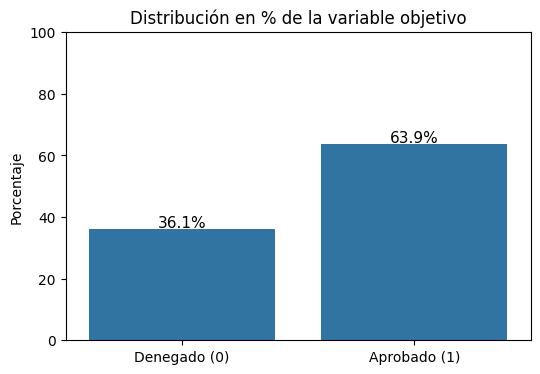

In [ ]:
target_counts = df_model['target'].value_counts(normalize=True).sort_index()*100

plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=11)

plt.title("Distribución en % de la variable objetivo")
plt.xlabel("")
plt.ylabel("Porcentaje")

plt.xticks([0,1], ['Denegado (0)','Aprobado (1)'])

plt.ylim(0,100)
plt.show()


## 2. Distribución de variables


In [ ]:
#Cojo las variables numericas excluyendo la variable target, 

num_vars = df_model.select_dtypes(include=['int64','float64']).columns
num_vars = num_vars.drop('target', 'anio_actividad' )


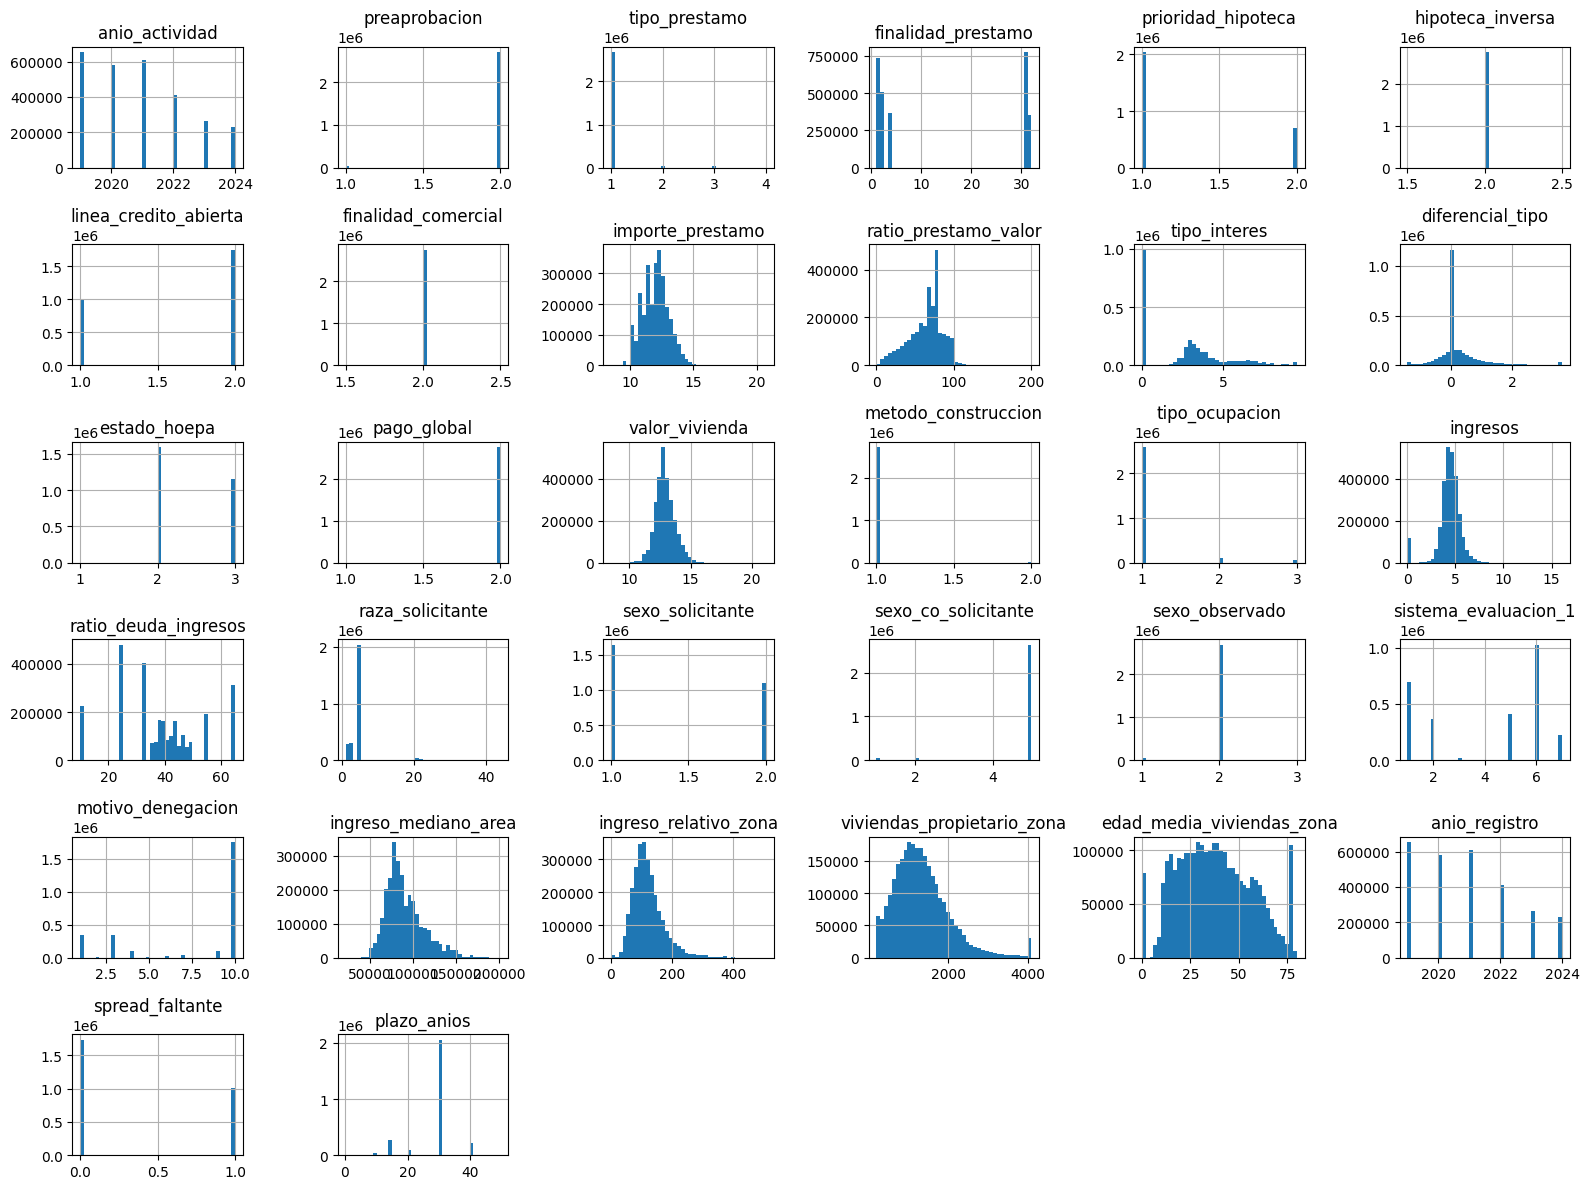

In [ ]:
df_model[num_vars].hist(bins=40, figsize=(16,12))
plt.tight_layout()


El análisis de las distribuciones revela que las variables financieras presentan asimetrías positivas, típicas en datos económicos, mientras que numerosas variables corresponden a categorías discretas codificadas numéricamente. Asimismo, variables como la ratio loan-to-value o el tipo de interés muestran rangos coherentes con las condiciones habituales del mercado hipotecario.


## 3. Variables vs target


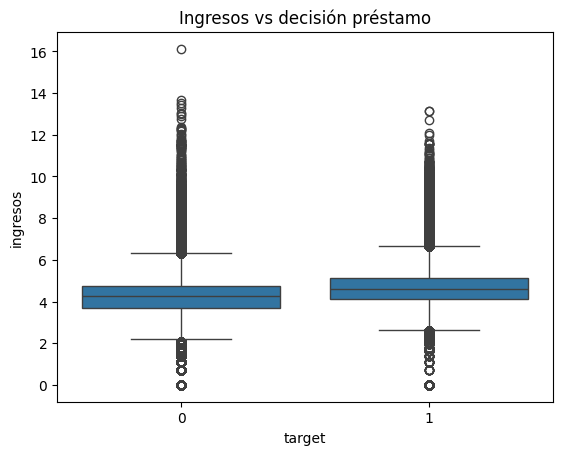

In [ ]:
sns.boxplot(x='target', y='ingresos', data=df_model)
plt.title("Ingresos vs decisión préstamo")
plt.show()


- La mediana de ingresos es mayor para target = 1 (préstamos aprobados).

- La distribución de ingresos de los aprobados está ligeramente desplazada hacia valores más altos.

- Hay bastante solapamiento entre ambos grupos.


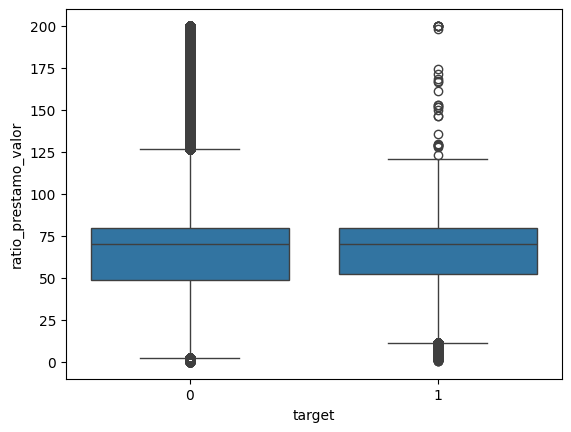

In [ ]:
sns.boxplot(x='target', y='ratio_prestamo_valor', data=df_model)
plt.show()


Observaciones:

- Las medianas de LTV son muy parecidas entre aprobados y denegados.

- La dispersión es similar en ambos grupos.

- No se aprecia una separación clara.

El LTV no parece ser un factor determinante por sí solo.


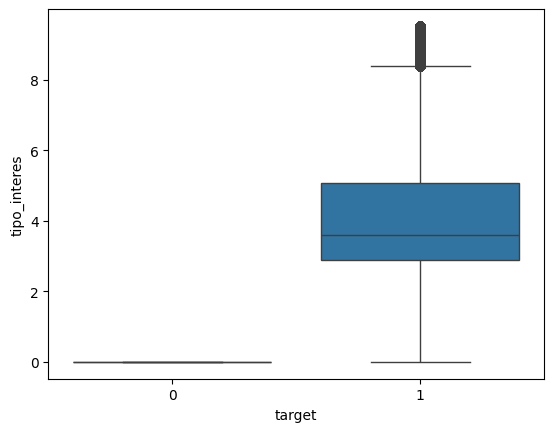

In [ ]:
sns.boxplot(x='target', y='tipo_interes', data=df_model)
plt.show()


## 4. Correlaciones


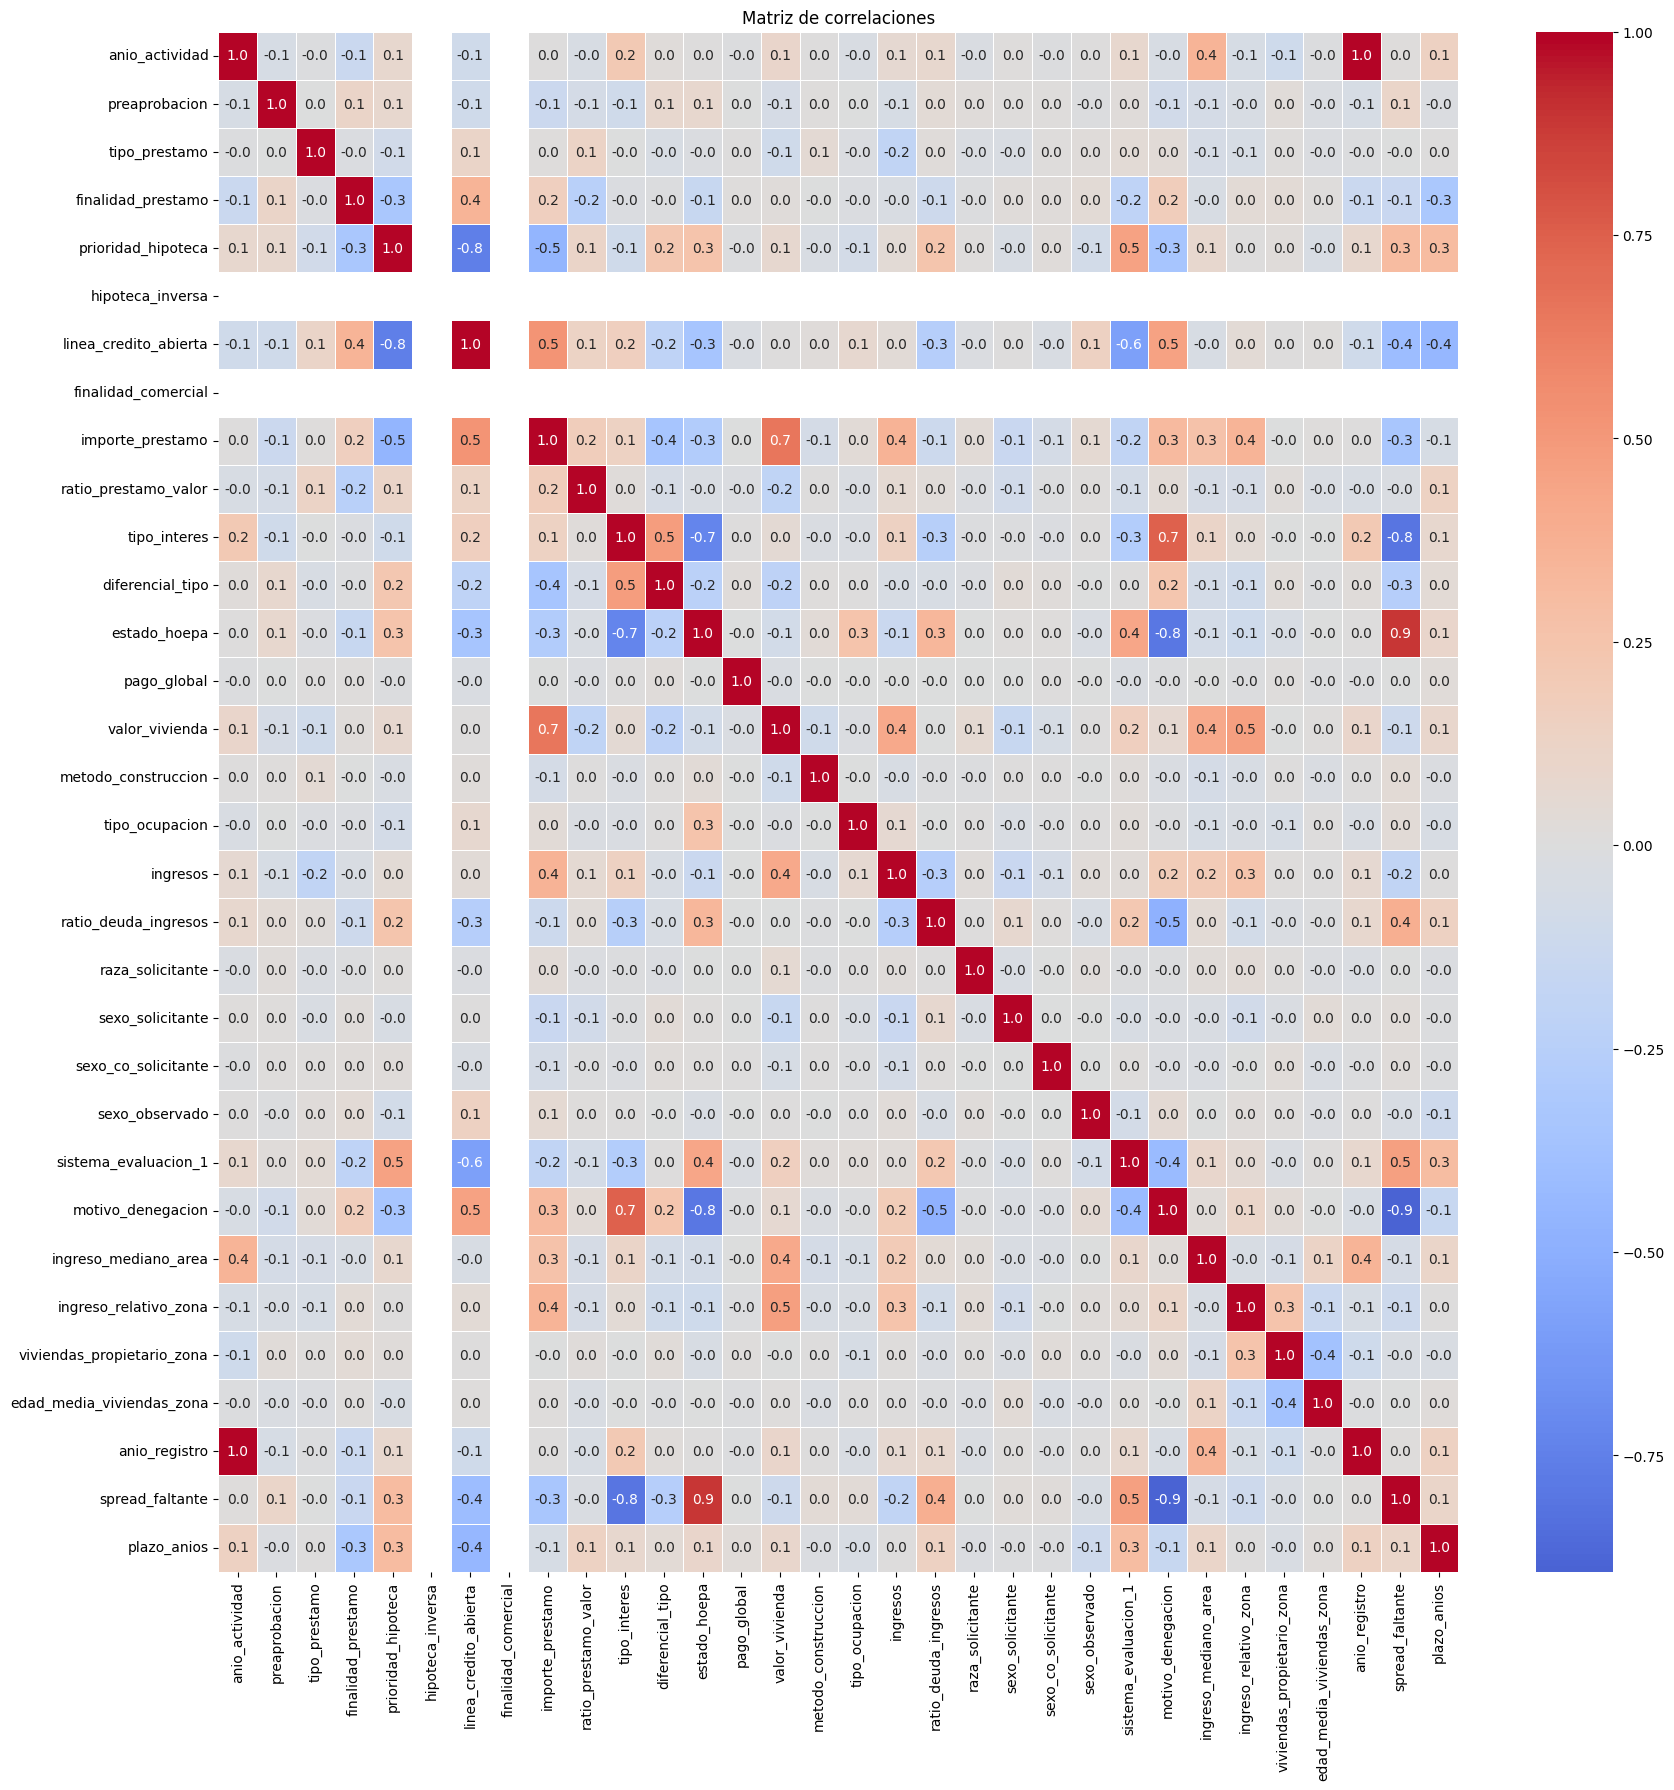

In [ ]:
corr = df_model[num_vars].corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True,fmt='.1f',cmap='coolwarm',center=0,linewidths=0.5)
plt.title("Matriz de correlaciones")
plt.show()


In [ ]:
df_model['sexo']


0          hombre
22         hombre
23         hombre
24         hombre
26         hombre
            ...  
4362589    hombre
4362590    hombre
4362591    hombre
4362593    hombre
4362596    hombre
Name: sexo, Length: 2743872, dtype: str

## 5. P-VALORES


In [ ]:
# Variables sensibles
sensitive_vars = ['sexo', 'etnia', 'raza']

def resumen_target_por_grupo(df, group_col, target_col='target'):
    temp = df[[group_col, target_col]].dropna().copy()
    
    resumen = temp.groupby(group_col)[target_col].agg(
        total='count',
        target_1='sum',
        tasa_1='mean',
        target_0=lambda x: (x == 0).sum(),
        tasa_0=lambda x: (x == 0).mean()
    ).reset_index().sort_values('tasa_1', ascending=False)
    
    resumen['tasa_1_pct'] = (resumen['tasa_1'] * 100).round(2)
    resumen['tasa_0_pct'] = (resumen['tasa_0'] * 100).round(2)
    
    return resumen

def chi_square_test(df, sensitive_col, target_col='target'):
    temp = df[[sensitive_col, target_col]].dropna().copy()
    tabla = pd.crosstab(temp[sensitive_col], temp[target_col])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    return {
        'variable_sensible': sensitive_col,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'significativo_0_05': p_value < 0.05
    }, tabla

def analizar_variables_sensibles(df, sensitive_vars, target_col='target'):
    resultados = []
    
    for var in sensitive_vars:
        print(f"\n{'='*60}")
        print(f"VARIABLE SENSIBLE: {var}")
        print(f"{'='*60}")
        
        # Resumen por grupo
        resumen = resumen_target_por_grupo(df, var, target_col)
        print("\nResumen por grupo:")
        print(resumen)
        
        # Tabla cruzada
        tabla_pct = pd.crosstab(df[var], df[target_col], normalize='index') * 100
        print("\nPorcentaje por fila:")
        print(tabla_pct.round(2))
        
        # Chi-cuadrado
        result, tabla = chi_square_test(df, var, target_col)
        print("\nTabla de contingencia:")
        print(tabla)
        print(f"\nchi2 = {result['chi2']:.4f}")
        print(f"p_value = {result['p_value']:.6f}")
        print(f"dof = {result['dof']}")
        print(f"significativo_0_05 = {result['significativo_0_05']}")
        
        resultados.append(result)
    
    resultados_df = pd.DataFrame(resultados).sort_values('p_value')
    return resultados_df


In [ ]:
resultados_finales = analizar_variables_sensibles(
    df=df_model,
    sensitive_vars=sensitive_vars,
    target_col='target'
)

print("\n" + "="*60)
print("RESUMEN FINAL DE P-VALORES")
print("="*60)
print(resultados_finales)



VARIABLE SENSIBLE: sexo

Resumen por grupo:
     sexo    total  target_1    tasa_1  target_0    tasa_0  tasa_1_pct  \
0  hombre  1643321   1065937  0.648648    577384  0.351352       64.86   
1   mujer  1100551    686559  0.623832    413992  0.376168       62.38   

   tasa_0_pct  
0       35.14  
1       37.62  

Porcentaje por fila:
target      0      1
sexo                
hombre  35.14  64.86
mujer   37.62  62.38

Tabla de contingencia:
target       0        1
sexo                   
hombre  577384  1065937
mujer   413992   686559

chi2 = 1758.8888
p_value = 0.000000
dof = 1
significativo_0_05 = True

VARIABLE SENSIBLE: etnia

Resumen por grupo:
                     etnia    total  target_1    tasa_1  target_0    tasa_0  \
4   Not Hispanic or Latino  2300855   1525936  0.663204    774919  0.336796   
3                    Joint    13537      7079  0.522937      6458  0.477063   
2       Hispanic or Latino   349075    181814  0.520845    167261  0.479155   
0  Ethnicity Not Availabl

In [ ]:
#Variables sensibles
sensitive_vars = ['sexo', 'etnia', 'raza']

def tabla_resumen_sensibles(df, sensitive_vars, target_col='target'):
    filas = []
    
    for var in sensitive_vars:
        temp = df[[var, target_col]].dropna().copy()
        
        # Resumen por grupo
        grp = temp.groupby(var)[target_col].agg(
            total='count',
            target_1='sum',
            tasa_1='mean'
        ).reset_index()
        
        grp['target_0'] = grp['total'] - grp['target_1']
        grp['tasa_0'] = 1 - grp['tasa_1']
        grp['tasa_1_pct'] = grp['tasa_1'] * 100
        grp['tasa_0_pct'] = grp['tasa_0'] * 100
        
        # Chi-cuadrado global
        tabla = pd.crosstab(temp[var], temp[target_col])
        chi2, p_value, dof, expected = chi2_contingency(tabla)
        
        # Métricas resumen
        max_row = grp.loc[grp['tasa_1'].idxmax()]
        min_row = grp.loc[grp['tasa_1'].idxmin()]
        
        diff_pp = (max_row['tasa_1'] - min_row['tasa_1']) * 100
        ratio_tasas = max_row['tasa_1'] / min_row['tasa_1'] if min_row['tasa_1'] != 0 else np.nan
        
        filas.append({
            'variable_sensible': var,
            'grupo_mayor_tasa_1': max_row[var],
            'mayor_tasa_1_pct': round(max_row['tasa_1_pct'], 2),
            'grupo_menor_tasa_1': min_row[var],
            'menor_tasa_1_pct': round(min_row['tasa_1_pct'], 2),
            'dif_pp_tasa_1': round(diff_pp, 2),
            'p_value': p_value,
            'significativo_0_05': p_value < 0.05
        })
    
    return pd.DataFrame(filas).sort_values('p_value')

tabla_resumen = tabla_resumen_sensibles(df_model, sensitive_vars, target_col='target')
tabla_resumen


,variable_sensible,grupo_mayor_tasa_1,mayor_tasa_1_pct,grupo_menor_tasa_1,menor_tasa_1_pct,dif_pp_tasa_1,p_value,significativo_0_05
0,sexo,hombre,64.86,mujer,62.38,2.48,0.0,True
1,etnia,Not Hispanic or Latino,66.32,Free Form Text Only,40.18,26.14,0.0,True
2,raza,Asian,68.22,Native Hawaiian or Other Pacific Islander,39.33,28.89,0.0,True


## 6. Multicolinealidad (VIF)


In [ ]:
X = df_model[num_vars].copy()

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,variable,VIF
0,anio_actividad,inf
29,anio_registro,inf
30,spread_faltante,12.388159
8,importe_prestamo,7.060249
12,estado_hoepa,6.752183
24,motivo_denegacion,6.242715
14,valor_vivienda,5.686294
10,tipo_interes,5.217808
6,linea_credito_abierta,4.409618
4,prioridad_hipoteca,4.251034


| VIF  | significado    |
| ---- | -------------- |
| <5   | OK             |
| 5–10 | revisar        |
| >10  | problema serio |


El análisis de multicolinealidad mediante el factor de inflación de la varianza (VIF) muestra que la mayoría de las variables presentan valores bajos, lo que indica ausencia de problemas significativos de multicolinealidad. Sin embargo, se detectaron valores infinitos en variables relacionadas con el año de registro, lo que refleja redundancia perfecta entre dichas variables. Asimismo, variables derivadas del plazo del préstamo presentan valores elevados debido a su dependencia estructural.


In [ ]:
df_model.shape


(2743872, 49)

## 7. PCA exploratorio


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

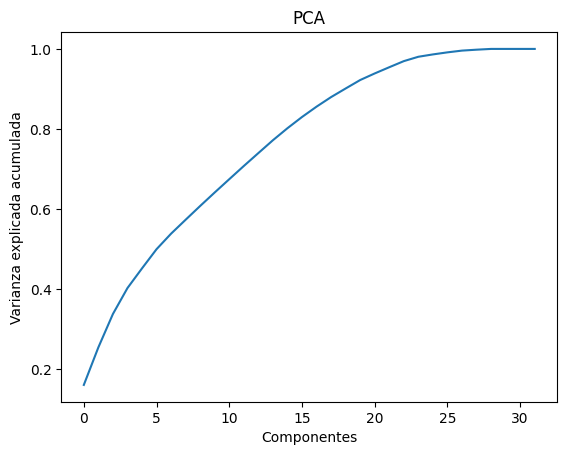

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA")
plt.show()


El análisis de componentes principales (PCA) muestra que la varianza explicada se distribuye de forma gradual entre los distintos componentes. Aproximadamente 15 componentes son necesarios para explicar alrededor del 85% de la varianza total, lo que sugiere que las variables del modelo aportan información relativamente diversa y no existe una fuerte redundancia entre ellas.


In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

loadings


,anio_actividad,preaprobacion,tipo_prestamo,finalidad_prestamo,prioridad_hipoteca,hipoteca_inversa,linea_credito_abierta,finalidad_comercial,importe_prestamo,ratio_prestamo_valor,...,sexo_observado,sistema_evaluacion_1,motivo_denegacion,ingreso_mediano_area,ingreso_relativo_zona,viviendas_propietario_zona,edad_media_viviendas_zona,anio_registro,spread_faltante,plazo_anios
0,2.194299e-02,5.955002e-02,-7.363164e-03,-1.408731e-01,2.598024e-01,-0.000000e+00,-3.137954e-01,-0.000000e+00,-2.459909e-01,-1.241249e-02,...,-4.999996e-02,2.788661e-01,-4.028254e-01,-3.194191e-02,-8.434618e-02,-2.422422e-02,-5.278977e-05,2.194299e-02,4.065831e-01,1.321308e-01
1,4.172224e-01,-7.796913e-02,-8.091159e-02,-1.999864e-01,2.280076e-01,0.000000e+00,-2.186816e-01,6.938894e-18,1.186187e-01,-1.013085e-02,...,-4.354360e-02,1.839596e-01,4.646340e-02,3.513813e-01,1.153569e-01,-5.447775e-02,2.547647e-02,4.172224e-01,-8.767466e-02,2.641753e-01
2,7.711720e-02,5.129946e-02,3.394843e-02,-1.129850e-01,1.755929e-01,-0.000000e+00,-1.887638e-01,-0.000000e+00,-4.324369e-01,2.510605e-02,...,-4.727435e-02,-4.709224e-02,1.528434e-01,-1.382305e-01,-2.751221e-01,-3.484474e-02,2.446694e-03,7.711720e-02,-1.710029e-01,9.598077e-02
3,4.136304e-01,-5.082493e-02,1.017506e-01,1.002416e-01,-2.942384e-01,-1.110223e-16,2.611270e-01,2.775558e-17,1.384533e-02,-3.866336e-02,...,6.920977e-02,-1.713950e-01,-8.177488e-02,1.609186e-01,-3.337431e-01,-2.858026e-01,1.868441e-01,4.136304e-01,9.527705e-02,-1.490003e-01
4,-8.718278e-02,-2.733795e-01,2.873728e-01,-4.219058e-01,5.160636e-03,-1.110223e-16,9.649954e-02,2.775558e-17,1.635257e-01,6.501877e-01,...,-1.973607e-02,-2.798288e-02,2.284437e-02,-7.440171e-02,-1.150343e-01,-1.135332e-01,6.791185e-02,-8.718278e-02,-2.047568e-02,2.652667e-01
5,-2.533299e-01,-5.872646e-03,-1.935127e-01,1.614945e-02,4.774552e-02,-1.110223e-16,-8.876562e-02,5.551115e-17,2.706403e-03,-1.249985e-01,...,-9.665664e-02,6.897510e-02,3.862921e-02,1.096446e-01,-2.030378e-01,-5.436477e-01,6.048775e-01,-2.533299e-01,-3.898632e-02,4.040281e-02
6,1.049098e-01,2.813004e-03,-2.192252e-01,-1.007437e-01,9.351224e-03,-0.000000e+00,3.084370e-02,-2.775558e-17,-9.712783e-02,5.501488e-02,...,1.921224e-01,-6.636060e-03,2.852816e-02,-1.451549e-01,-5.670224e-02,-1.510593e-02,-1.296371e-01,1.049098e-01,4.085439e-02,-1.628381e-01
7,7.754610e-03,3.331690e-01,5.589654e-01,1.807461e-01,-3.463109e-02,0.000000e+00,-1.914302e-02,-4.423545e-17,5.767655e-02,-1.150883e-01,...,-1.756580e-01,2.202920e-01,5.944649e-02,1.185517e-03,3.020639e-02,-1.086499e-01,9.596470e-02,7.754610e-03,-2.243694e-02,6.185544e-02
8,-1.542191e-03,2.670690e-01,4.068700e-02,7.267444e-03,1.130626e-01,-1.209970e-16,-8.083692e-04,-3.265617e-16,-1.725413e-02,1.503732e-01,...,4.815632e-01,-6.670272e-02,-3.079677e-02,1.110396e-01,-1.047487e-01,-6.284625e-02,5.085011e-02,-1.542191e-03,1.302976e-02,-1.116342e-01
9,-1.444931e-03,3.051514e-02,-5.598850e-03,2.371643e-02,-4.856901e-02,9.194034e-17,7.808601e-03,-1.713039e-16,5.754801e-02,2.317411e-02,...,-1.044538e-01,-7.632587e-02,-1.107866e-02,3.146873e-02,-5.119307e-02,1.516717e-02,-4.351333e-02,-1.444931e-03,-1.491365e-02,1.030393e-01


- 0 : PC1
- 1 : PC2

cada componente principal es una combinación lineal de todas las variables originales, Significa que puedes reducir el dataset a 15 dimensiones sin perder mucha informaciÓN

PC1=a1​X1​+a2​X2​+a3​X3​+...+an​Xn​


Vamos a hacer el gráfico más útil del PCA: PC1 vs PC2 coloreado por target


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [ ]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "target": df_model["target"]
})


El objetivo del PCA fue explorar la estructura del conjunto de datos y comprobar si existía separabilidad entre las clases antes de entrenar el modelo.


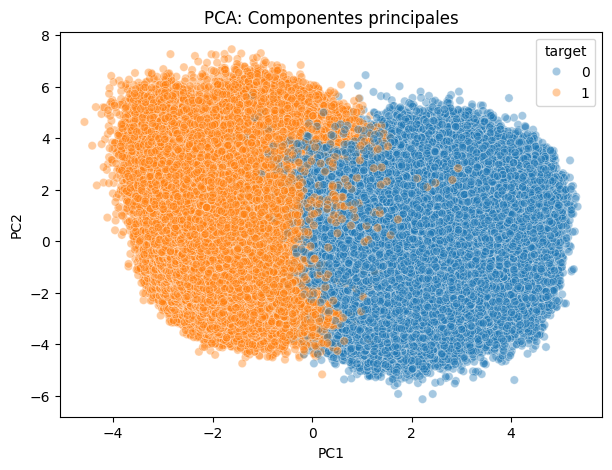

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target",
    alpha=0.4
)

plt.title("PCA: Componentes principales")
plt.show()


Se observa que:

- target = 1 (aprobados) se concentra más en la parte derecha y superior.

- target = 0 (denegados) aparece más en la parte izquierda e inferior.

existe estructura en los datos pero hay bastante zona de solapamiento en el centro por lo que la decisión de concesión no depende de una sola dimensión


El PCA revela cierta estructura en los datos y una separación parcial entre aprobaciones y denegaciones, lo que indica que las variables financieras contienen información útil para el proceso de clasificación.


SOLAPAMIENTO

En el gráfico se observa una zona de solapamiento entre ambas clases, lo que indica que algunos solicitantes aprobados y denegados presentan características similares según las variables analizadas. Esto sugiere que la decisión de concesión de crédito depende de la combinación de múltiples factores y no puede explicarse únicamente mediante las dos dimensiones principales representadas. Y sugiere que la separación  no es completamente lineal.


Cambiar a otro notebook el DataFrame


In [ ]:
df_model.to_pickle("data/processed/df_model.pkl")


## 3.8 Comprobaciones finales


In [ ]:
df_model['spread_faltante'].value_counts()


spread_faltante
0    1733496
1    1010376
Name: count, dtype: int64

In [ ]:
df_model['diferencial_tipo'].shape


(2743872,)

In [ ]:
df_model


,anio_actividad,codigo_estado,limite_prestamo_conforme,tipo_producto_prestamo,categoria_vivienda,etnia,raza,sexo,preaprobacion,tipo_prestamo,...,motivo_denegacion,ingreso_mediano_area,ingreso_relativo_zona,viviendas_propietario_zona,edad_media_viviendas_zona,anio_registro,target,spread_faltante,plazo_anios,grupo_plazo
0,2019,PA,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,3,66800,113.0,844,43,2019,0,1,18.0,15-20y
22,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,97900,166.0,4090,13,2019,1,0,40.0,30-40y
23,2019,CA,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,hombre,2,1,...,10,73100,260.0,1200,57,2019,1,0,40.0,30-40y
24,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,64800,75.0,1190,38,2019,1,0,40.0,30-40y
26,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,73100,114.0,953,71,2019,1,0,40.0,30-40y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362589,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,81600,123.0,1949,25,2024,1,0,30.0,20-30y
4362590,2024,OR,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,116900,141.0,1766,46,2024,1,0,30.0,20-30y
4362591,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,103300,159.0,1985,19,2024,1,0,30.0,20-30y
4362593,2024,WY,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,91800,175.0,898,27,2024,1,0,30.0,20-30y


In [ ]:
df_model['diferencial_tipo'].value_counts()


diferencial_tipo
 0.00000    1012445
 3.62000      27464
-1.40200      27452
 1.24000       1836
 0.35000       1699
             ...   
 1.22074          1
 1.77741          1
-0.28645          1
 1.79671          1
-0.49877          1
Name: count, Length: 166881, dtype: int64

In [ ]:
df['denial_reason-2'].isna().sum()


np.int64(4054891)

In [ ]:
df['denial_reason-3'].isna().sum()


np.int64(4298794)

In [ ]:
df['denial_reason-4'].isna().sum()


np.int64(4356672)

In [ ]:
df_model


,anio_actividad,codigo_estado,limite_prestamo_conforme,tipo_producto_prestamo,categoria_vivienda,etnia,raza,sexo,preaprobacion,tipo_prestamo,...,motivo_denegacion,ingreso_mediano_area,ingreso_relativo_zona,viviendas_propietario_zona,edad_media_viviendas_zona,anio_registro,target,spread_faltante,plazo_anios,grupo_plazo
0,2019,PA,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,3,66800,113.0,844,43,2019,0,1,18.0,15-20y
22,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,97900,166.0,4090,13,2019,1,0,40.0,30-40y
23,2019,CA,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,hombre,2,1,...,10,73100,260.0,1200,57,2019,1,0,40.0,30-40y
24,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,64800,75.0,1190,38,2019,1,0,40.0,30-40y
26,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,73100,114.0,953,71,2019,1,0,40.0,30-40y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362589,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,81600,123.0,1949,25,2024,1,0,30.0,20-30y
4362590,2024,OR,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,116900,141.0,1766,46,2024,1,0,30.0,20-30y
4362591,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,103300,159.0,1985,19,2024,1,0,30.0,20-30y
4362593,2024,WY,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,91800,175.0,898,27,2024,1,0,30.0,20-30y


In [ ]:
df.shape


(4363601, 100)

In [ ]:
df_model.shape


(2743872, 49)

In [ ]:
print('nos quedamos con el:', (49/100)*100, '% del dataset')


nos quedamos con el: 49.0 % del dataset


In [ ]:
df_model['plazo_anios']


0          18.0
22         40.0
23         40.0
24         40.0
26         40.0
           ... 
4362589    30.0
4362590    30.0
4362591    30.0
4362593    30.0
4362596    30.0
Name: plazo_anios, Length: 2743872, dtype: float64

In [ ]:
df_model


,anio_actividad,codigo_estado,limite_prestamo_conforme,tipo_producto_prestamo,categoria_vivienda,etnia,raza,sexo,preaprobacion,tipo_prestamo,...,motivo_denegacion,ingreso_mediano_area,ingreso_relativo_zona,viviendas_propietario_zona,edad_media_viviendas_zona,anio_registro,target,spread_faltante,plazo_anios,grupo_plazo
0,2019,PA,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,3,66800,113.0,844,43,2019,0,1,18.0,15-20y
22,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,97900,166.0,4090,13,2019,1,0,40.0,30-40y
23,2019,CA,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,hombre,2,1,...,10,73100,260.0,1200,57,2019,1,0,40.0,30-40y
24,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,64800,75.0,1190,38,2019,1,0,40.0,30-40y
26,2019,CA,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,73100,114.0,953,71,2019,1,0,40.0,30-40y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362589,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,81600,123.0,1949,25,2024,1,0,30.0,20-30y
4362590,2024,OR,NC,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,116900,141.0,1766,46,2024,1,0,30.0,20-30y
4362591,2024,OH,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,103300,159.0,1985,19,2024,1,0,30.0,20-30y
4362593,2024,WY,NC,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,hombre,2,1,...,10,91800,175.0,898,27,2024,1,0,30.0,20-30y


In [ ]:
df_model.groupby('anio_actividad')['target'].agg(['mean', 'count', 'sum'])


,mean,count,sum
anio_actividad,,,
2019,0.585668,652359,382066
2020,0.671949,582434,391366
2021,0.731747,607949,444865
2022,0.605246,410027,248167
2023,0.554860,262832,145835
2024,0.614169,228271,140197


In [ ]:
df_model.groupby('anio_actividad')['target'].agg(
    mean=lambda x: (x == 1).mean(),
    count='count',
    sum=lambda x: (x == 1).sum()
)


,mean,count,sum
anio_actividad,,,
2019,0.585668,652359,382066
2020,0.671949,582434,391366
2021,0.731747,607949,444865
2022,0.605246,410027,248167
2023,0.554860,262832,145835
2024,0.614169,228271,140197


In [ ]:
df_model.groupby('anio_actividad')['target'].agg(
    rate_0=lambda x: (x == 0).mean(),
    count='count',
    sum_0=lambda x: (x == 0).sum()
)


,rate_0,count,sum_0
anio_actividad,,,
2019,0.414332,652359,270293
2020,0.328051,582434,191068
2021,0.268253,607949,163084
2022,0.394754,410027,161860
2023,0.445140,262832,116997
2024,0.385831,228271,88074


In [ ]:
df_model.groupby(['anio_actividad', 'sexo', 'raza'])['target'].agg(
    mean=lambda x: (x == 1).mean(),
    count='count',
    sum=lambda x: (x == 1).sum()
)


mean  \
anio_actividad sexo   raza                                                  
2019           hombre 2 or more minority races                   0.361842   
                      American Indian or Alaska Native           0.360028   
                      Asian                                      0.668137   
                      Black or African American                  0.403490   
                      Native Hawaiian or Other Pacific Islander  0.302808   
...                                                                   ...   
2024           mujer  American Indian or Alaska Native           0.414172   
                      Asian                                      0.641319   
                      Black or African American                  0.494932   
                      Native Hawaiian or Other Pacific Islander  0.413690   
                      White                                      0.625624   

                                                                 count    sum  
anio_actividad sexo   raza                                                     
2019           hombre 2 or more minority races                    1216    440  
                      American Indian or Alaska Native            4358   1569  
                      Asian                                      58021  38766  
                      Black or African American                  29282  11815  
                      Native Hawaiian or Other Pacific Islander   3953   1197  
...                                                                ...    ...  
2024           mujer  American Indian or Alaska Native            1002    415  
                      Asian                                       9981   6401  
                      Black or African American                  18152   8984  
                      Native Hawaiian or Other Pacific Islander    336    139  
                      White                                      64454  40324  

[72 rows x 3 columns]

In [ ]:
df['derived_ethnicity'].value_counts()


derived_ethnicity
Not Hispanic or Latino     3668750
Hispanic or Latino          539407
Ethnicity Not Available     118716
Joint                        21376
Free Form Text Only          15352
Name: count, dtype: int64

In [ ]:
df_model['raza'].value_counts()


raza
White                                        2029738
Asian                                         362539
Black or African American                     300793
American Indian or Alaska Native               28057
Native Hawaiian or Other Pacific Islander      13407
2 or more minority races                        9338
Name: count, dtype: int64

In [ ]:
df_model.groupby(['anio_actividad', 'sexo', 'raza'])['target'].agg(
    mean=lambda x: (x == 0).mean(),
    count='count',
    sum=lambda x: (x == 0).sum()
)


mean  \
anio_actividad sexo   raza                                                  
2019           hombre 2 or more minority races                   0.638158   
                      American Indian or Alaska Native           0.639972   
                      Asian                                      0.331863   
                      Black or African American                  0.596510   
                      Native Hawaiian or Other Pacific Islander  0.697192   
...                                                                   ...   
2024           mujer  American Indian or Alaska Native           0.585828   
                      Asian                                      0.358681   
                      Black or African American                  0.505068   
                      Native Hawaiian or Other Pacific Islander  0.586310   
                      White                                      0.374376   

                                                                 count    sum  
anio_actividad sexo   raza                                                     
2019           hombre 2 or more minority races                    1216    776  
                      American Indian or Alaska Native            4358   2789  
                      Asian                                      58021  19255  
                      Black or African American                  29282  17467  
                      Native Hawaiian or Other Pacific Islander   3953   2756  
...                                                                ...    ...  
2024           mujer  American Indian or Alaska Native            1002    587  
                      Asian                                       9981   3580  
                      Black or African American                  18152   9168  
                      Native Hawaiian or Other Pacific Islander    336    197  
                      White                                      64454  24130  

[72 rows x 3 columns]

In [ ]:
df['derived_ethnicity'].value_counts()


derived_ethnicity
Not Hispanic or Latino     3668750
Hispanic or Latino          539407
Ethnicity Not Available     118716
Joint                        21376
Free Form Text Only          15352
Name: count, dtype: int64

In [ ]:
df_model.groupby(['anio_actividad', 'etnia'])['target'].agg(
    mean=lambda x: (x == 0).mean(),
    count='count',
    sum=lambda x: (x == 0).sum()
)


mean   count     sum
anio_actividad etnia                                            
2019           Ethnicity Not Available  0.604447   14031    8481
               Free Form Text Only      0.696097    2152    1498
               Hispanic or Latino       0.543075   85734   46560
               Joint                    0.546738    3541    1936
               Not Hispanic or Latino   0.387306  546901  211818
2020           Ethnicity Not Available  0.503834   14737    7425
               Free Form Text Only      0.590065    2154    1271
               Hispanic or Latino       0.427011   64366   27485
               Joint                    0.421588    2557    1078
               Not Hispanic or Latino   0.308469  498620  153809
2021           Ethnicity Not Available  0.420233   16241    6825
               Free Form Text Only      0.513466    2822    1449
               Hispanic or Latino       0.361092   69816   25210
               Joint                    0.401332    2853    1145
               Not Hispanic or Latino   0.248839  516217  128455
2022           Ethnicity Not Available  0.575672   10975    6318
               Free Form Text Only      0.601959    1736    1045
               Hispanic or Latino       0.520915   54506   28393
               Joint                    0.522415    2186    1142
               Not Hispanic or Latino   0.366862  340624  124962
2023           Ethnicity Not Available  0.578891    7428    4300
               Free Form Text Only      0.643013     916     589
               Hispanic or Latino       0.569349   39568   22528
               Joint                    0.556407    1436     799
               Not Hispanic or Latino   0.415867  213484   88781
2024           Ethnicity Not Available  0.473082    6204    2935
               Free Form Text Only      0.596630    1009     602
               Hispanic or Latino       0.486960   35085   17085
               Joint                    0.371369     964     358
               Not Hispanic or Latino   0.362653  185009   67094

In [ ]:
df_model[df_model['target'] == 1]['target'].corr(df_model[df_model['target'] == 1]['tipo_interes'])


c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jgilsanzmu001\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(nan)

In [ ]:
corr = df_model['target'].corr(df_model['tipo_interes'])
print(corr)


0.8206840131936235


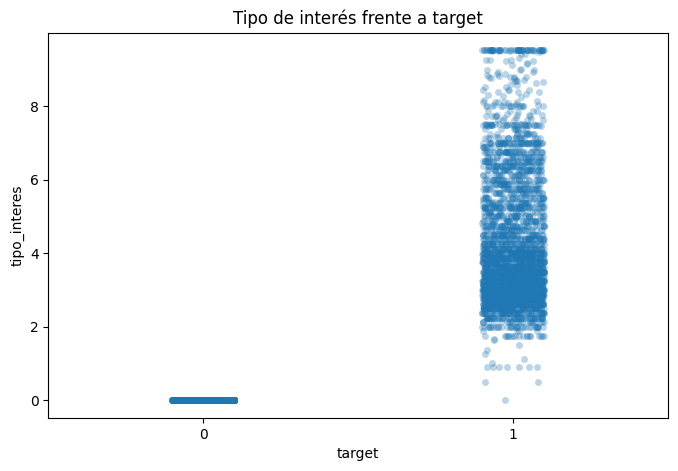

In [ ]:
plt.figure(figsize=(8,5))
sns.stripplot(data=df_model.sample(min(len(df_model), 5000), random_state=42),
              x='target', y='tipo_interes', alpha=0.3, jitter=True)
plt.title('Tipo de interés frente a target')
plt.show()


In [ ]:
df_model.columns


Index(['anio_actividad', 'codigo_estado', 'limite_prestamo_conforme',
       'tipo_producto_prestamo', 'categoria_vivienda', 'etnia', 'raza', 'sexo',
       'preaprobacion', 'tipo_prestamo', 'finalidad_prestamo',
       'prioridad_hipoteca', 'hipoteca_inversa', 'linea_credito_abierta',
       'finalidad_comercial', 'importe_prestamo', 'ratio_prestamo_valor',
       'tipo_interes', 'diferencial_tipo', 'estado_hoepa', 'pago_global',
       'valor_vivienda', 'metodo_construccion', 'tipo_ocupacion',
       'numero_unidades', 'ingresos', 'ratio_deuda_ingresos',
       'etnia_solicitante', 'etnia_co_solicitante', 'raza_solicitante',
       'raza_co_solicitante', 'sexo_solicitante', 'sexo_co_solicitante',
       'sexo_observado', 'edad_solicitante', 'edad_co_solicitante',
       'solicitante_mayor_62', 'co_solicitante_mayor_62',
       'sistema_evaluacion_1', 'motivo_denegacion', 'ingreso_mediano_area',
       'ingreso_relativo_zona', 'viviendas_propietario_zona',
       'edad_media_viviendas

In [ ]:
pares = [
    ('etnia', 'etnia_solicitante'),
    ('raza', 'raza_solicitante'),
    ('sexo', 'sexo_solicitante')
]

for col1, col2 in pares:
    mask = df_model[col1].notna() & df_model[col2].notna()
    igualdad = (df_model.loc[mask, col1] == df_model.loc[mask, col2]).mean()
    print(f'{col1} vs {col2}: {igualdad:.4f}')
    print(pd.crosstab(df_model[col1], df_model[col2], normalize='index'))
    print('-' * 50)


etnia vs etnia_solicitante: 0.0000
etnia_solicitante             1.0      2.0       3.0       4.0      11.0  \
etnia                                                                      
Ethnicity Not Available  0.000000  0.00000  0.999986  0.000014  0.000000   
Free Form Text Only      0.000000  0.00000  0.000000  0.000000  0.000000   
Hispanic or Latino       0.813181  0.00000  0.000000  0.000000  0.060984   
Joint                    0.279752  0.68383  0.000000  0.000000  0.007239   
Not Hispanic or Latino   0.000000  1.00000  0.000000  0.000000  0.000000   

etnia_solicitante            12.0      13.0      14.0  Unknown  
etnia                                                           
Ethnicity Not Available  0.000000  0.000000  0.000000      0.0  
Free Form Text Only      0.000000  0.000000  0.000000      1.0  
Hispanic or Latino       0.018217  0.016128  0.091490      0.0  
Joint                    0.004358  0.003029  0.021792      0.0  
Not Hispanic or Latino   0.000000  0.00000

['anio_registro',
    'metodo_construccion',
    'sexo_observado',
    'sexo_co_solicitante',
    'viviendas_propietario_zona',
    'edad_media_viviendas_zona'
    'co_solicitante_mayor_62',
    'numero_unidades',
    'finalidad_comercial',
    'hipoteca_inversa',
    'linea_credito_abierta',
    'prioridad_hipoteca'
    'sexo'
    'raza',
    'etnia'
    'diferencial_tipo',
    'estado_hoepa',
    'pago_global',
    'motivo_denegacion',
    'spread_faltante',
    'plazo_anios',
    'grupo_plazo', 
    'limite_prestamo_conforme'
]


In [ ]:
cols_eliminaar = [
    'anio_registro',
    'metodo_construccion',
    'sexo_observado',
    'sexo_co_solicitante',
    'viviendas_propietario_zona',
    'edad_media_viviendas_zona',
    'co_solicitante_mayor_62',
    'numero_unidades',
    'finalidad_comercial',
    'hipoteca_inversa',
    'linea_credito_abierta',
    'prioridad_hipoteca',
    'sexo_solicitante',
    'raza_solicitante',
    'etnia_solicitante',
    'diferencial_tipo',
    'estado_hoepa',
    'pago_global',
    'motivo_denegacion',
    'spread_faltante',
    'plazo_anios',
    'grupo_plazo',
    'tipo_interes',
    'limite_prestamo_conforme'
]


In [ ]:
df_model = df_model.drop(columns=cols_eliminaar, errors='ignore')


In [ ]:
df_model.shape


(2743872, 25)

In [ ]:
df_model.to_pickle("data/processed/df_model.pkl")


In [ ]:
df_model.groupby(['anio_actividad', 'raza'])['target'].agg(
    mean=lambda x: (x == 0).mean(),
    count='count',
    sum=lambda x: (x == 0).sum()
)


mean   count  \
anio_actividad raza                                                          
2019           2 or more minority races                   0.644960    2242   
               American Indian or Alaska Native           0.641155    6964   
               Asian                                      0.356784   86324   
               Black or African American                  0.588628   63225   
               Native Hawaiian or Other Pacific Islander  0.697716    6216   
               White                                      0.393998  487388   
2020           2 or more minority races                   0.519340    1758   
               American Indian or Alaska Native           0.541336    5165   
               Asian                                      0.291929   82609   
               Black or African American                  0.472886   50325   
               Native Hawaiian or Other Pacific Islander  0.517333    1875   
               White                                      0.314215  440702   
2021           2 or more minority races                   0.460619    1841   
               American Indian or Alaska Native           0.453060    5752   
               Asian                                      0.229961   80505   
               Black or African American                  0.412353   63710   
               Native Hawaiian or Other Pacific Islander  0.422558    1853   
               White                                      0.251081  454288   
2022           2 or more minority races                   0.580666    1531   
               American Indian or Alaska Native           0.575465    4459   
               Asian                                      0.361643   52397   
               Black or African American                  0.530673   51951   
               Native Hawaiian or Other Pacific Islander  0.566712    1484   
               White                                      0.372381  298205   
2023           2 or more minority races                   0.606838    1053   
               American Indian or Alaska Native           0.611591    3123   
               Asian                                      0.407443   31467   
               Black or African American                  0.552329   38640   
               Native Hawaiian or Other Pacific Islander  0.628520    1101   
               White                                      0.424614  187448   
2024           2 or more minority races                   0.559693     913   
               American Indian or Alaska Native           0.562452    2594   
               Asian                                      0.342716   29237   
               Black or African American                  0.514268   32942   
               Native Hawaiian or Other Pacific Islander  0.582005     878   
               White                                      0.362582  161707   

                                                             sum  
anio_actividad raza                                               
2019           2 or more minority races                     1446  
               American Indian or Alaska Native             4465  
               Asian                                       30799  
               Black or African American                   37216  
               Native Hawaiian or Other Pacific Islander    4337  
               White                                      192030  
2020           2 or more minority races                      913  
               American Indian or Alaska Native             2796  
               Asian                                       24116  
               Black or African American                   23798  
               Native Hawaiian or Other Pacific Islander     970  
               White                                      138475  
2021           2 or more minority races                      848  
               American Indian or Alaska Native             2606  
               Asian     

In [ ]:
df_model.groupby(['anio_actividad', 'raza'])['target'].agg(
    mean=lambda x: (x == 1).mean(),
    count='count',
    sum=lambda x: (x == 1).sum()
)


mean   count  \
anio_actividad raza                                                          
2019           2 or more minority races                   0.355040    2242   
               American Indian or Alaska Native           0.358845    6964   
               Asian                                      0.643216   86324   
               Black or African American                  0.411372   63225   
               Native Hawaiian or Other Pacific Islander  0.302284    6216   
               White                                      0.606002  487388   
2020           2 or more minority races                   0.480660    1758   
               American Indian or Alaska Native           0.458664    5165   
               Asian                                      0.708071   82609   
               Black or African American                  0.527114   50325   
               Native Hawaiian or Other Pacific Islander  0.482667    1875   
               White                                      0.685785  440702   
2021           2 or more minority races                   0.539381    1841   
               American Indian or Alaska Native           0.546940    5752   
               Asian                                      0.770039   80505   
               Black or African American                  0.587647   63710   
               Native Hawaiian or Other Pacific Islander  0.577442    1853   
               White                                      0.748919  454288   
2022           2 or more minority races                   0.419334    1531   
               American Indian or Alaska Native           0.424535    4459   
               Asian                                      0.638357   52397   
               Black or African American                  0.469327   51951   
               Native Hawaiian or Other Pacific Islander  0.433288    1484   
               White                                      0.627619  298205   
2023           2 or more minority races                   0.393162    1053   
               American Indian or Alaska Native           0.388409    3123   
               Asian                                      0.592557   31467   
               Black or African American                  0.447671   38640   
               Native Hawaiian or Other Pacific Islander  0.371480    1101   
               White                                      0.575386  187448   
2024           2 or more minority races                   0.440307     913   
               American Indian or Alaska Native           0.437548    2594   
               Asian                                      0.657284   29237   
               Black or African American                  0.485732   32942   
               Native Hawaiian or Other Pacific Islander  0.417995     878   
               White                                      0.637418  161707   

                                                             sum  
anio_actividad raza                                               
2019           2 or more minority races                      796  
               American Indian or Alaska Native             2499  
               Asian                                       55525  
               Black or African American                   26009  
               Native Hawaiian or Other Pacific Islander    1879  
               White                                      295358  
2020           2 or more minority races                      845  
               American Indian or Alaska Native             2369  
               Asian                                       58493  
               Black or African American                   26527  
               Native Hawaiian or Other Pacific Islander     905  
               White                                      302227  
2021           2 or more minority races                      993  
               American Indian or Alaska Native             3146  
               Asian     

In [ ]:
df_model.groupby(['anio_actividad', 'sexo'])['target'].agg(
    mean=lambda x: (x == 0).mean(),
    count='count',
    sum=lambda x: (x == 0).sum()
)


mean   count     sum
anio_actividad sexo                            
2019           hombre  0.398793  395348  157662
               mujer   0.438234  257011  112631
2020           hombre  0.319935  357942  114518
               mujer   0.340992  224492   76550
2021           hombre  0.261743  356873   93409
               mujer   0.277506  251076   69675
2022           hombre  0.386028  245078   94607
               mujer   0.407720  164949   67253
2023           hombre  0.434729  154188   67030
               mujer   0.459915  108644   49967
2024           hombre  0.374615  133892   50158
               mujer   0.401742   94379   37916